# 🎯 MASTER Workflow - Complete Interactive Clustering Pipeline

**Purpose**: End-to-end interactive clustering analysis with full control over every step

**What you can do**:
- ✅ Import and inspect raw data
- ✅ Configure preprocessing parameters
- ✅ Detect and handle outliers with visualization
- ✅ Toggle PCA on/off and see the impact
- ✅ Select feature sets (static/dynamic/combined)
- ✅ Run K-Means with adjustable k
- ✅ Run Hierarchical clustering with different linkage methods
- ✅ Run DBSCAN with interactive parameter tuning
- ✅ Compare all algorithms side-by-side
- ✅ Backtrack and re-run sections with different settings

**Navigation**: Each section is independent - jump to any step!

---

## 📑 Table of Contents

1. [Setup & Environment](#section-1)
2. [Data Import & Inspection](#section-2)
3. [Data Preprocessing & Formatting](#section-3)
4. [Outlier Detection & Handling](#section-4)
5. [Feature Selection](#section-5)
6. [PCA Configuration (Toggle)](#section-6)
7. [Data Scaling & Preparation](#section-7)
8. [K-Means Clustering](#section-8)
9. [Hierarchical Clustering](#section-9)
10. [DBSCAN Clustering](#section-10)
11. [Algorithm Comparison](#section-11)
12. [Results Export](#section-12)

---

## 1️⃣ Setup & Environment

Load all required libraries and set up the environment.

In [ ]:
# ============================================================================
# 📦 IMPORTS
# ============================================================================

# Standard libraries
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization - Static
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization - Interactive (Plotly)
import plotly.graph_objects as go
import plotly.express as px
import plotly.offline as pyo
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)
from sklearn.neighbors import NearestNeighbors

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Interactive widgets (optional, with fallback)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
    print("✅ ipywidgets available - full interactivity enabled")
except ImportError:
    WIDGETS_AVAILABLE = False
    print("⚠️ ipywidgets not available - some interactive features disabled")

# Project modules
sys.path.insert(0, str(Path.cwd().parent))
from src._01_setup import config_loader
from src._02_preprocessing import data_cleaner

# Notebook utilities (includes all interactive functions)
from notebook_utils import (
    setup_notebook,
    NotebookState,
    display_dataframe_summary,
    create_interactive_scatter,
    create_interactive_cluster_distribution,
    create_interactive_heatmap,
    create_parallel_coordinates,
    create_metrics_dashboard,
    create_k_distance_plot,
    compare_clusters_interactive
)

# Configure plotting
pyo.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")

## 🎛️ Market & Data Selection

Configure which market and files to analyze.

In [ ]:
# ============================================================================
# 🎛️ MARKET & DATA SELECTION - Multi-Market Support
# ============================================================================

# ====================
# OPTION 1: Use Preset (Recommended for common scenarios)
# ====================
USE_PRESET = 'germany_dax_family'  # Set to preset name or None for manual config

# Available presets:
# - 'germany_dax_family': Top 160 deutsche Unternehmen (DAX+MDAX+SDAX)
# - 'europe_large_cap': Top 50 aus DEU, FRA, GBR, ITA, ESP (250 total)
# - 'germany_vs_france': Top 40 aus DEU und FRA (80 total)
# - 'all_europe': Alle Unternehmen aus 10 EU-Ländern
# - 'usa_large_cap': Top 500 US Unternehmen (S&P 500 Proxy)
# - 'global_giants': Top Unternehmen aus USA, DEU, GBR, FRA, JPN, CHN

# To see all presets with descriptions:
# from src._02_preprocessing.data_loader import list_available_presets
# print(list_available_presets())

# ====================
# OPTION 2: Manual Configuration (Advanced)
# ====================
MANUAL_CONFIG = {
    'mode': 'single',  # 'single' oder 'multi'
    'countries': ['DEU'],  # Ländercodes (z.B. ['DEU', 'FRA', 'ITA'])
    'use_index_proxy': True,
    'index_proxies': {
        'DEU': {'type': 'top_n', 'n': 160},
        # 'FRA': {'type': 'top_n', 'n': 40},
        # Mehr Optionen:
        # {'type': 'range', 'start': 1, 'end': 100}  # Rang 1-100
        # {'type': 'percentile', 'percentile': 90}   # Top 10%
        # {'type': 'all'}                             # Alle Unternehmen
    },
    'exclude_sectors': [40],  # GICS Sektor-Codes zum Ausschließen (40=Financials, 60=Real Estate)
    'min_company_size': None  # Optional: Minimum Market Value/Assets
}

# ====================
# DATA SOURCE
# ====================
# Pfad zur großen internationalen CSV (relativ zu data/raw/ oder absolut)
INTERNATIONAL_CSV = 'vusvw30hpcipn91t.csv'  # Deine große WRDS CSV
USE_MULTI_MARKET = True  # True = nutze internationale CSV, False = nutze alte Ordner-Struktur

# Legacy Support: Falls USE_MULTI_MARKET = False
MARKET = 'germany'  # Default für Legacy-Modus
FILE_SELECTION = None
FILTER_COUNTRY = None  # Legacy parameter

print("="*80)
print("🌍 MARKET CONFIGURATION")
print("="*80)

if USE_MULTI_MARKET:
    if USE_PRESET:
        print(f"\n✅ Using Preset: '{USE_PRESET}'")
        from src._02_preprocessing.data_loader import get_preset_config
        try:
            preset_config = get_preset_config(USE_PRESET)
            print(f"   {preset_config.get('description', '')}")
            print(f"   Countries: {preset_config['countries']}")
            print(f"   Mode: {preset_config['mode']}")
            # Set MARKET based on preset
            if len(preset_config['countries']) == 1:
                MARKET = preset_config['countries'][0].lower()
            else:
                MARKET = f"multi_{len(preset_config['countries'])}countries"
        except ValueError as e:
            print(f"   ⚠️  {e}")
            print("   → Fallback to MANUAL_CONFIG")
            USE_PRESET = None
            # Set MARKET from manual config
            if len(MANUAL_CONFIG['countries']) == 1:
                MARKET = MANUAL_CONFIG['countries'][0].lower()
            else:
                MARKET = f"multi_{len(MANUAL_CONFIG['countries'])}countries"
    else:
        print("\n⚙️  Using Manual Configuration")
        print(f"   Countries: {MANUAL_CONFIG['countries']}")
        print(f"   Mode: {MANUAL_CONFIG['mode']}")
        print(f"   Index Proxy: {MANUAL_CONFIG.get('use_index_proxy', False)}")
        # Set MARKET based on manual config
        if len(MANUAL_CONFIG['countries']) == 1:
            MARKET = MANUAL_CONFIG['countries'][0].lower()
        else:
            MARKET = f"multi_{len(MANUAL_CONFIG['countries'])}countries"
else:
    print(f"\n📁 Legacy Mode: Single Market from Directory")
    print(f"   Market: {MARKET}")

print("="*80)

In [ ]:
# ============================================================================
# 🔍 OPTIONAL: Discover Available Countries (nur ausführen wenn neugierig)
# ============================================================================

# Auskommentieren um verfügbare Länder zu sehen:
# from src._02_preprocessing.data_loader import discover_available_countries
# from pathlib import Path

# csv_path = Path(PROJECT_ROOT) / 'data' / 'raw' / INTERNATIONAL_CSV
# if csv_path.exists():
#     print("🔍 Analysiere verfügbare Länder in CSV...\n")
#     country_stats = discover_available_countries(str(csv_path))
#     print("\n📊 Verfügbare Länder (Top 20):\n")
#     print(country_stats.head(20).to_string(index=False))
# else:
#     print(f"⚠️  CSV nicht gefunden: {csv_path}")
#     print("   (Das ist OK wenn die Datei nur auf deinem lokalen Computer liegt)")

print("💡 Diese Zelle ist optional - zum Aktivieren Kommentare entfernen")

In [ ]:
# ============================================================================
# 📋 LOAD CONFIGURATION
# ============================================================================

from src._01_setup import config_loader

# Load config.yaml
cfg = config_loader.load_config('config.yaml')

print("✅ Configuration loaded:")
print(f"  📊 Market: {cfg['data']['market']}")
print(f"  🔢 Random State: {cfg['global']['random_state']}")
print(f"  🎯 K-Range: {cfg['cluster_selection']['k_range']}")
print(f"  📐 PCA Enabled: {cfg['pca']['enabled']}")
print(f"  ⚙️  Scaling Method: {cfg['preprocessing']['scaling']['method']}")

In [ ]:
# ============================================================================
# 📤 INITIALIZE OUTPUT HANDLER
# ============================================================================

from src._01_setup.output_coordinator import OutputHandler

# Create OutputHandler for current market
output_handler = OutputHandler(
    market=MARKET,
    algorithm='kmeans',  # Default algorithm (can be changed per section)
    mode='auto',
    base_dir='output'
)

print("✅ OutputHandler initialized:")
print(f"  📊 Market: {output_handler.market}")
print(f"  📁 Output Dir: {output_handler.market_dir}")
print(f"  🎯 Algorithm: {output_handler.algorithm_name}")
print(f"  🔧 Mode: {output_handler.mode}")

## 2️⃣ Data Import & Inspection

Load configuration and raw data files.

In [ ]:
# Setup notebook and load configuration
cfg, state = setup_notebook(
    title="MASTER Workflow - Complete Pipeline",
    market=MARKET
)

# Extract key configuration
market = config_loader.get_value(cfg, 'data', 'market', default=MARKET)
input_dir = str(PROJECT_ROOT / config_loader.get_value(cfg, 'data', 'input_dir', default='data/raw'))

print(f"\n📋 Configuration Loaded:")
print(f"  Market: {market}")
print(f"  Input Directory: {input_dir}")
print(f"\n✅ Configuration ready!")

In [3]:
# Locate data files
data_dir = PROJECT_ROOT / input_dir / market

print(f"📁 Data Directory: {data_dir}")
print(f"\nAvailable files:")

if data_dir.exists():
    files = sorted(data_dir.glob('*.csv'))
    for i, f in enumerate(files, 1):
        size_mb = f.stat().st_size / 1024**2
        print(f"  {i}. {f.name:50s} ({size_mb:8.2f} MB)")
    
    if not files:
        print("  ⚠️  No CSV files found!")
else:
    print(f"  ⚠️  Directory not found: {data_dir}")

📁 Data Directory: /Users/tobi/Documents/GitHub/Masterarbeit-Kennzahlenanalyse/data/raw/germany

Available files:
  1. dax40_proxy.csv                                    (    0.73 MB)
  2. mdax_proxy.csv                                     (    1.06 MB)
  3. sdax_proxy.csv                                     (    1.63 MB)


In [ ]:
# Load market data - supports both single-market and multi-market modes
from src._02_preprocessing import data_loader

if USE_MULTI_MARKET:
    # Multi-Market Mode: Load from international CSV
    print(f"\n🌍 Multi-Market Loading Mode")
    
    # Determine config to use
    if USE_PRESET:
        print(f"  Using preset: {USE_PRESET}")
        market_config = data_loader.get_preset_config(USE_PRESET)
    else:
        print(f"  Using manual configuration")
        market_config = MANUAL_CONFIG
    
    print(f"  Mode: {market_config['mode']}")
    print(f"  Countries: {market_config['countries']}")
    
    # Load data with multi-market function
    df_raw = data_loader.load_multi_market_data(
        csv_path=INTERNATIONAL_CSV,
        market_config=market_config,
        data_dir='data/raw'
    )
else:
    # Legacy Mode: Single-market loading from separate CSV files
    print(f"\n📊 Single-Market Loading Mode (Legacy)")
    print(f"  Market: {MARKET}")
    
    df_raw = data_loader.load_market_data(
        market=MARKET,
        data_dir='data/raw',
        file_selection=FILE_SELECTION,
        filter_country=FILTER_COUNTRY
    )

# Display loaded data info
print(f"\n📊 Loaded Data:")
print(f"  Rows: {len(df_raw):,}")
print(f"  Columns: {len(df_raw.columns)}")
if 'gvkey' in df_raw.columns:
    print(f"  Companies: {df_raw['gvkey'].nunique()}")
if 'fyear' in df_raw.columns:
    years = df_raw['fyear'].dropna().unique()
    if len(years) > 0:
        print(f"  Years: {int(min(years))} - {int(max(years))}")

# Show country distribution if multi-market
if USE_MULTI_MARKET and 'source_country' in df_raw.columns:
    print(f"\n🌍 Country Distribution:")
    country_counts = df_raw['source_country'].value_counts()
    for country, count in country_counts.items():
        pct = count / len(df_raw) * 100
        print(f"  {country}: {count:,} rows ({pct:.1f}%)")

## 3️⃣ Data Preprocessing & Formatting

**Configure preprocessing parameters and run the pipeline.**

You can adjust these settings and re-run this section at any time.

In [4]:
# ============================================================================
# 🎛️ PREPROCESSING CONFIGURATION - ADJUST THESE PARAMETERS
# ============================================================================

# Imputation settings
IMPUTE_ENABLED = True           # Enable/disable missing value imputation
IMPUTE_METHOD = 'mean'        # Options: 'mean', 'median', 'zero'
IMPUTE_THRESHOLD = 0.5          # Drop columns with >50% missing values

# Feature engineering
SMOOTH_STATIC = False           # Apply smoothing to static features
CAGR_YEARS = 3                  # Number of years for CAGR calculation

# Display configuration
print("🎛️ Preprocessing Configuration:")
print("=" * 80)
print(f"  Imputation Enabled:     {IMPUTE_ENABLED}")
print(f"  Imputation Method:      {IMPUTE_METHOD}")
print(f"  Imputation Threshold:   {IMPUTE_THRESHOLD} ({IMPUTE_THRESHOLD*100:.0f}% missing)")
print(f"  Smooth Static Features: {SMOOTH_STATIC}")
print(f"  CAGR Years:             {CAGR_YEARS}")
print("=" * 80)

🎛️ Preprocessing Configuration:
  Imputation Enabled:     True
  Imputation Method:      mean
  Imputation Threshold:   0.5 (50% missing)
  Smooth Static Features: False
  CAGR Years:             3


In [5]:
# Run preprocessing pipeline
print("\n🔄 Running preprocessing pipeline...\n")

df_features = data_cleaner.run_preprocessing(
    input_dir=input_dir,
    market=market,
    impute=IMPUTE_ENABLED,
    impute_method=IMPUTE_METHOD,
    impute_threshold=IMPUTE_THRESHOLD,
    smooth_static=SMOOTH_STATIC,
    cagr_years=CAGR_YEARS
)

print("\n✅ Preprocessing complete!")
display_dataframe_summary(df_features, "Processed Features")


🔄 Running preprocessing pipeline...



Fehlende Spalten: {'ni'}
  ⚠ Extreme Werte in gsubind: min=15101010, max=55105020



✅ Preprocessing complete!

📊 Processed Features Summary
--------------------------------------------------------------------------------
Shape: 1,602 rows × 149 columns
Memory: 1.49 MB

Columns: rect, sale, gvkey, loc, dvt, gsubind, isin, xrd, cogs, seq ... (+139 more)
--------------------------------------------------------------------------------


In [6]:
# Preview processed data
print("\n📊 Data Preview:")
display(df_features.head(10))

print(f"\n📈 Data Shape: {df_features.shape[0]:,} rows × {df_features.shape[1]:,} columns")


📊 Data Preview:


,rect,sale,gvkey,loc,dvt,gsubind,isin,xrd,cogs,seq,...,capex_growth_outlier,margin_trend_outlier,leverage_trend_outlier,capex_trend_outlier,fcf_trend_outlier,margin_volatility_outlier,leverage_volatility_outlier,cashflow_volatility_outlier,margin_consistency_outlier,growth_quality_outlier
1193,11432.0,74326.0,17436,DEU,2572.0,15101020.0,DE000BASF111,1884.0,53133.0,27614.0,...,False,False,False,False,False,False,False,False,False,False
1194,10630.0,70449.0,17436,DEU,2664.0,15101020.0,DE000BASF111,1953.0,48115.0,30916.0,...,False,False,False,False,False,False,False,False,False,False
1195,11978.0,57550.0,17436,DEU,2755.0,15101020.0,DE000BASF111,1863.0,35698.0,31807.0,...,False,False,False,False,False,False,False,False,False,False
1196,12275.0,64475.0,17436,DEU,2847.0,15101020.0,DE000BASF111,1888.0,40191.0,33837.0,...,False,False,False,False,False,False,False,False,False,False
1197,12008.0,62675.0,17436,DEU,2939.0,15101020.0,DE000BASF111,2028.0,41485.0,35054.0,...,False,False,False,False,False,False,False,False,False,False
1198,10664.0,59316.0,17436,DEU,3030.0,15101020.0,DE000BASF111,2158.0,39615.0,41497.0,...,False,False,False,False,False,False,False,False,False,False
1199,11181.0,59149.0,17436,DEU,3031.0,15101020.0,DE000BASF111,2086.0,40512.0,33728.0,...,False,False,False,False,False,False,False,False,False,False
1200,14282.0,78598.0,17436,DEU,3123.0,15101020.0,DE000BASF111,2216.0,55548.0,40792.0,...,False,False,False,False,False,False,False,False,False,False
1201,14645.0,87327.0,17436,DEU,3039.0,15101020.0,DE000BASF111,2298.0,62897.0,39573.0,...,False,False,False,False,False,False,False,False,False,False
1202,12360.0,68902.0,17436,DEU,3035.0,15101020.0,DE000BASF111,2130.0,48737.0,35277.0,...,False,False,False,False,False,False,False,False,False,False



📈 Data Shape: 1,602 rows × 149 columns


In [7]:
# Prepare time-series datasets
print("\n🔄 Preparing time-series datasets...\n")

df_all, df_latest = data_cleaner.prepare_time_data(df_features, market)

print("✅ Time-series preparation complete!\n")
display_dataframe_summary(df_all, "All Time Periods")
display_dataframe_summary(df_latest, "Latest Snapshot")

# Save to state
state.save('df_features', df_features)
state.save('df_all', df_all)
state.save('df_latest', df_latest)


🔄 Preparing time-series datasets...

✅ Time-series preparation complete!


📊 All Time Periods Summary
--------------------------------------------------------------------------------
Shape: 1,602 rows × 151 columns
Memory: 1.50 MB

Columns: rect, sale, gvkey, loc, dvt, gsubind, isin, xrd, cogs, seq ... (+141 more)
--------------------------------------------------------------------------------

📊 Latest Snapshot Summary
--------------------------------------------------------------------------------
Shape: 160 rows × 151 columns
Memory: 0.15 MB

Columns: rect, sale, gvkey, loc, dvt, gsubind, isin, xrd, cogs, seq ... (+141 more)
--------------------------------------------------------------------------------
✓ Saved 'df_features' to state (type: DataFrame)
✓ Saved 'df_all' to state (type: DataFrame)
✓ Saved 'df_latest' to state (type: DataFrame)


## 4️⃣ Outlier Detection & Handling

**Visualize outliers and understand their impact.**

In [8]:
# Identify feature types
numeric_cols = df_latest.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['company_id', 'gvkey', 'year', 'fyear', 'cluster', 'label', 'latest_year', 'gsector', 'gsubind', 'ggroup']
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

# Categorize features
static_features = [f for f in feature_cols if not any(x in f for x in ['_trend', '_volatility', '_cagr', '_growth'])]
dynamic_features = [f for f in feature_cols if any(x in f for x in ['_trend', '_volatility', '_cagr', '_growth'])]

print(f"\n📊 Feature Overview:")
print("=" * 80)
print(f"  Total Features:        {len(feature_cols)}")
print(f"  Static Features:       {len(static_features)}")
print(f"  Dynamic Features:      {len(dynamic_features)}")
print("=" * 80)

print(f"\n📌 Static Features ({len(static_features)}):")
for i, f in enumerate(static_features[:15], 1):
    print(f"  {i:2d}. {f}")
if len(static_features) > 15:
    print(f"      ... and {len(static_features) - 15} more")

print(f"\n📈 Dynamic Features ({len(dynamic_features)}):")
for i, f in enumerate(dynamic_features[:15], 1):
    print(f"  {i:2d}. {f}")
if len(dynamic_features) > 15:
    print(f"      ... and {len(dynamic_features) - 15} more")

# Save feature lists
state.save('feature_cols', feature_cols)
state.save('static_features', static_features)
state.save('dynamic_features', dynamic_features)


📊 Feature Overview:
  Total Features:        87
  Static Features:       75
  Dynamic Features:      12

📌 Static Features (75):
   1. rect
   2. sale
   3. dvt
   4. xrd
   5. cogs
   6. seq
   7. revt
   8. naics
   9. fincf
  10. xint
  11. capx
  12. invt
  13. ivst
  14. dltt
  15. at
      ... and 60 more

📈 Dynamic Features (12):
   1. revenue_growth
   2. asset_growth
   3. employee_growth
   4. fcf_growth
   5. capex_growth
   6. margin_trend
   7. leverage_trend
   8. capex_trend
   9. fcf_trend
  10. margin_volatility
  11. leverage_volatility
  12. cashflow_volatility
✓ Saved 'feature_cols' to state (type: list)
✓ Saved 'static_features' to state (type: list)
✓ Saved 'dynamic_features' to state (type: list)


In [9]:
# Detect outliers using IQR method
def detect_outliers_iqr(df, features, multiplier=1.5):
    """Detect outliers using IQR method"""
    outlier_info = []
    
    for col in features:
        if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
            continue
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outlier_pct = outliers / len(df) * 100
        
        if outliers > 0:
            outlier_info.append({
                'Feature': col,
                'Outliers': outliers,
                'Percentage': outlier_pct,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound
            })
    
    return pd.DataFrame(outlier_info).sort_values('Percentage', ascending=False)

# Detect outliers
outlier_summary = detect_outliers_iqr(df_latest, feature_cols[:20])  # First 20 features

print("\n🔍 Outlier Detection (Top 15 features with most outliers):")
print("=" * 80)
if len(outlier_summary) > 0:
    display(outlier_summary.head(15))
else:
    print("  ✅ No outliers detected!")
print("=" * 80)


🔍 Outlier Detection (Top 15 features with most outliers):


,Feature,Outliers,Percentage,Lower_Bound,Upper_Bound
7,fincf,35,21.875,-1055.967125,665.355875
11,ivst,29,18.125,-224.625000,374.375000
5,seq,27,16.875,-7056.373125,13793.411875
12,dltt,26,16.250,-3356.518750,6641.511250
13,at,24,15.000,-21483.595625,42120.317375
14,ppent,22,13.750,-5237.416250,9922.529750
4,cogs,22,13.750,-12440.794097,23552.467496
9,capx,19,11.875,-958.241250,1830.944750
17,che,19,11.875,-2927.426250,5302.855750
8,xint,18,11.250,-253.810615,493.469691


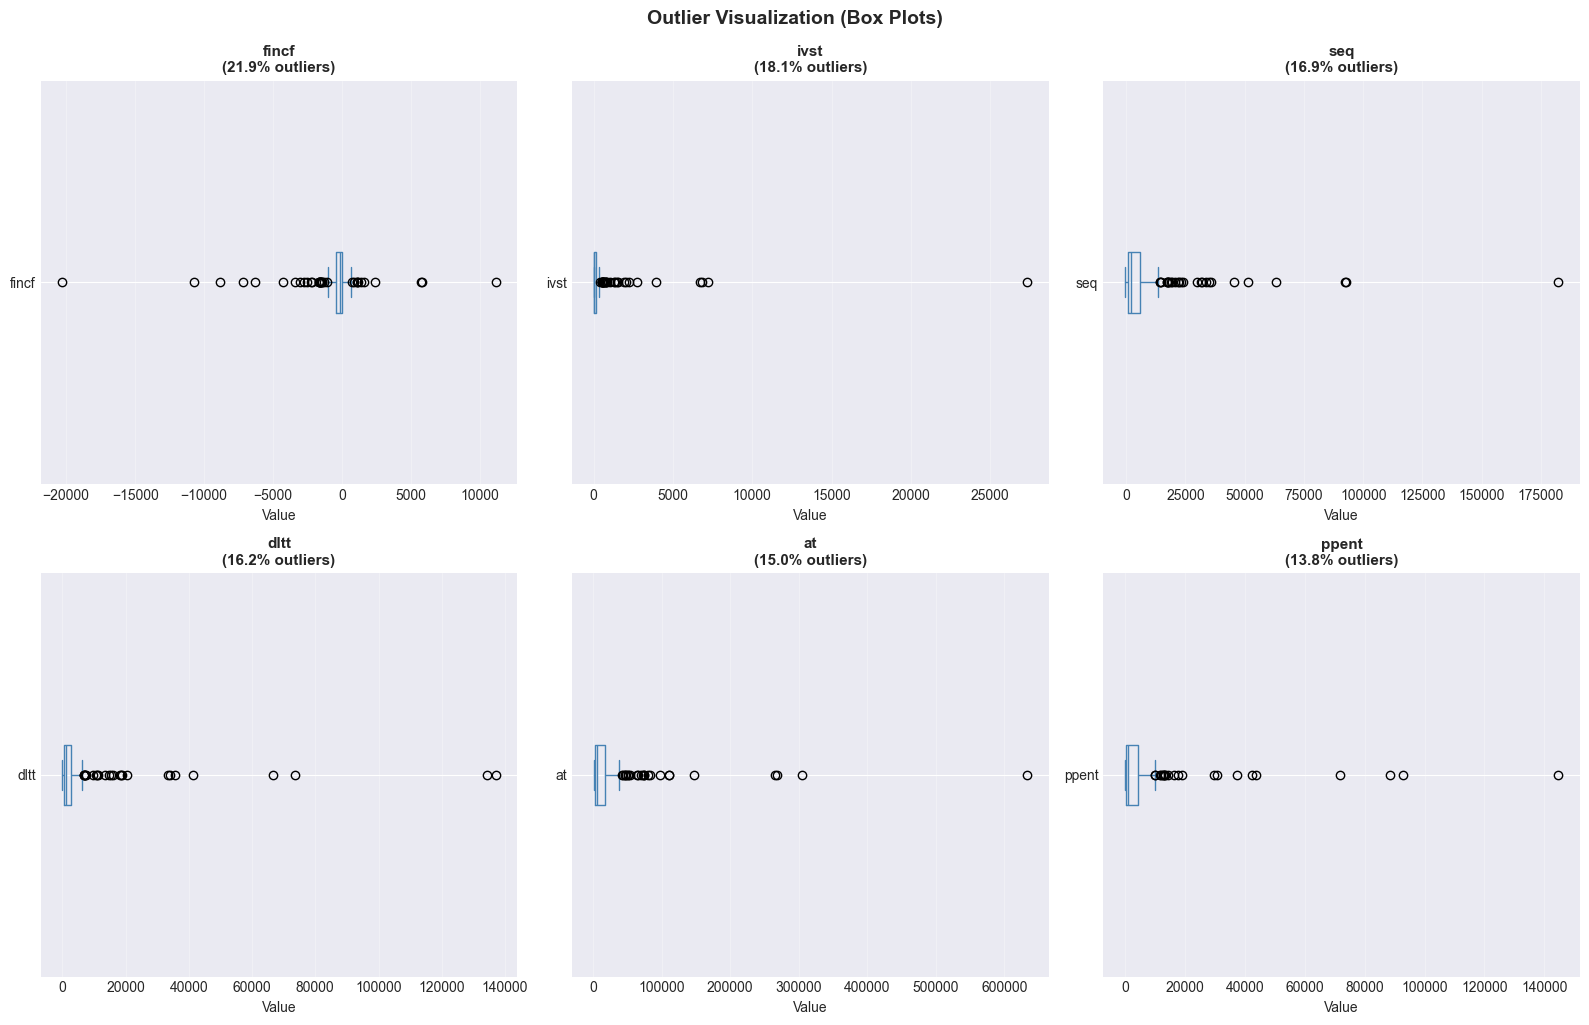

In [10]:
# Visualize outliers for top features
if len(outlier_summary) > 0:
    top_outlier_features = outlier_summary.head(6)['Feature'].tolist()
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_outlier_features):
        ax = axes[idx]
        
        # Box plot
        df_latest[feature].plot(kind='box', ax=ax, vert=False, color='steelblue')
        ax.set_xlabel('Value', fontsize=10)
        ax.set_title(f'{feature}\n({outlier_summary[outlier_summary["Feature"]==feature]["Percentage"].values[0]:.1f}% outliers)',
                    fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Outlier Visualization (Box Plots)', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("✅ No outliers to visualize")

## 5️⃣ Feature Selection

**Choose which features to use for clustering.**

Options:
- `'static'`: Current financial ratios only
- `'dynamic'`: Time-series features only (trends, volatility, growth)
- `'combined'`: All features together

In [11]:
# ============================================================================
# 🎛️ FEATURE SELECTION - ADJUST THIS PARAMETER
# ============================================================================

FEATURE_SET = 'combined'  # Options: 'static', 'dynamic', 'combined'

# Select features based on choice
if FEATURE_SET == 'static':
    selected_features = static_features
elif FEATURE_SET == 'dynamic':
    selected_features = dynamic_features
else:  # combined
    selected_features = feature_cols

print(f"\n🎯 Feature Selection:")
print("=" * 80)
print(f"  Selected Set:    {FEATURE_SET.upper()}")
print(f"  Features Count:  {len(selected_features)}")
print("=" * 80)

if len(selected_features) <= 20:
    print(f"\n📋 Selected Features:")
    for i, f in enumerate(selected_features, 1):
        print(f"  {i:2d}. {f}")
else:
    print(f"\n📋 Selected Features (first 20 of {len(selected_features)}):")
    for i, f in enumerate(selected_features[:20], 1):
        print(f"  {i:2d}. {f}")
    print(f"      ... and {len(selected_features) - 20} more")

# Save selection
state.save('selected_features', selected_features)
state.save('feature_set_type', FEATURE_SET)


🎯 Feature Selection:
  Selected Set:    COMBINED
  Features Count:  87

📋 Selected Features (first 20 of 87):
   1. rect
   2. sale
   3. dvt
   4. xrd
   5. cogs
   6. seq
   7. revt
   8. naics
   9. fincf
  10. xint
  11. capx
  12. invt
  13. ivst
  14. dltt
  15. at
  16. gind
  17. ppent
  18. emp
  19. ivch
  20. che
      ... and 67 more
✓ Saved 'selected_features' to state (type: list)
✓ Saved 'feature_set_type' to state (type: str)


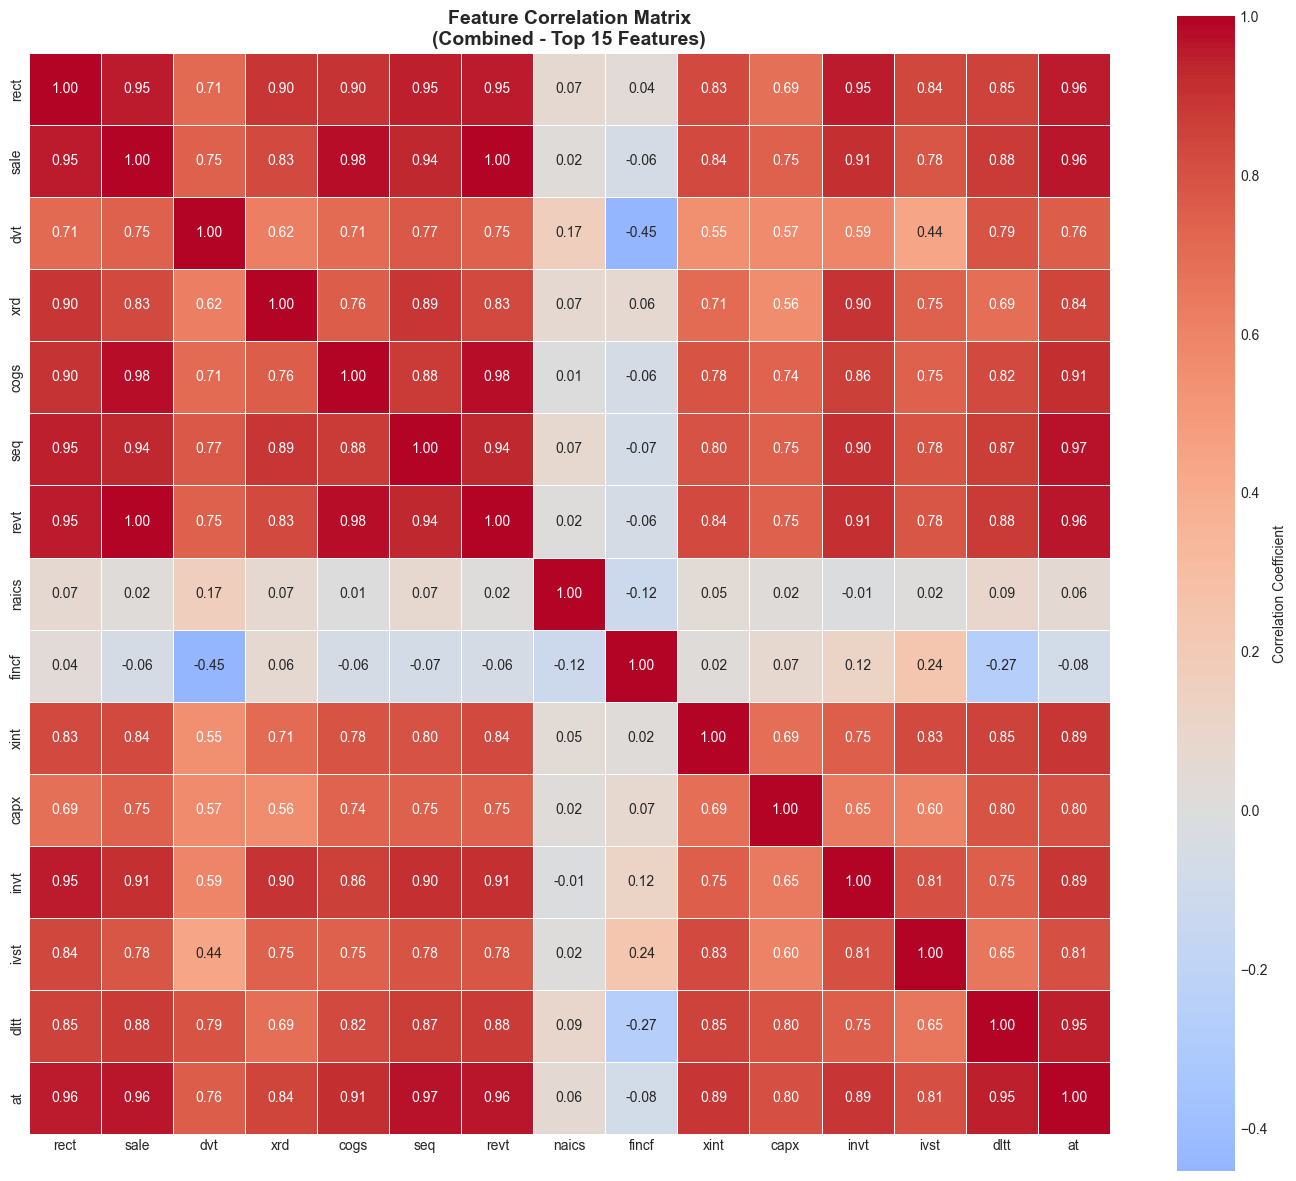


⚠️  Highly Correlated Pairs (|r| > 0.8):
  • rect                           <-> sale                            (r =  0.953)
  • rect                           <-> xrd                             (r =  0.895)
  • rect                           <-> cogs                            (r =  0.902)
  • rect                           <-> seq                             (r =  0.945)
  • rect                           <-> revt                            (r =  0.952)
  • rect                           <-> xint                            (r =  0.831)
  • rect                           <-> invt                            (r =  0.949)
  • rect                           <-> ivst                            (r =  0.836)
  • rect                           <-> dltt                            (r =  0.853)
  • rect                           <-> at                              (r =  0.958)
  • sale                           <-> xrd                             (r =  0.834)
  • sale                          

In [12]:
# Feature correlation analysis
top_n = min(15, len(selected_features))
corr_features = selected_features[:top_n]

df_corr = df_latest[corr_features].fillna(df_latest[corr_features].median())
corr_matrix = df_corr.corr()

# Interactive correlation heatmap
fig = create_interactive_heatmap(
    corr_matrix,
    title='Feature Correlation Matrix',
    x_label='Features',
    y_label='Features',
    colorscale='RdBu_r',
    show_values=True,
    width=1200,
    height=1000
)
fig.show()

# Find highly correlated pairs
high_corr_threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"\n⚠️  Highly Correlated Pairs (|r| > {high_corr_threshold}):")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  • {feat1:30s} <-> {feat2:30s}  (r = {corr_val:6.3f})")
else:
    print(f"\n✅ No highly correlated pairs found (threshold: {high_corr_threshold})")

## 6️⃣ PCA Configuration (Toggle)

**Enable or disable PCA and configure parameters.**

PCA (Principal Component Analysis) reduces dimensionality while preserving variance.

**When to use PCA:**
- Many features (>10)
- High feature correlation
- Curse of dimensionality issues

**When to skip PCA:**
- Few features (<10)
- Need interpretability
- Features already well-separated

In [13]:
# ============================================================================
# 🎛️ PCA CONFIGURATION
# ============================================================================

USE_PCA = cfg['pca']['enabled']
PCA_VARIANCE_THRESHOLD = cfg['pca']['n_components']

print(f"\n🎛️ PCA Configuration:")
print("=" * 80)
print(f"  PCA Enabled:           {USE_PCA}")
if USE_PCA:
    print(f"  Variance Threshold:    {PCA_VARIANCE_THRESHOLD} ({PCA_VARIANCE_THRESHOLD*100:.0f}%)")
print("=" * 80)


🎛️ PCA Configuration:
  PCA Enabled:           True
  Variance Threshold:    0.85 (85%)


In [14]:
# Prepare clustering dataset
df_cluster = df_latest[selected_features].copy()

# Handle missing values
df_cluster = df_cluster.fillna(df_cluster.median())

print(f"\n📊 Clustering Dataset:")
print(f"  Samples:         {len(df_cluster):,}")
print(f"  Features:        {len(selected_features)}")
print(f"  Missing Values:  {df_cluster.isnull().sum().sum()}")
print(f"  Memory Usage:    {df_cluster.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


📊 Clustering Dataset:
  Samples:         160
  Features:        87
  Missing Values:  0
  Memory Usage:    0.11 MB



🔄 Applying PCA...

✅ PCA Applied!
  Original Features:     87
  PCA Components:        19
  Dimensionality Reduction: 78.2%
  Explained Variance:    86.1%


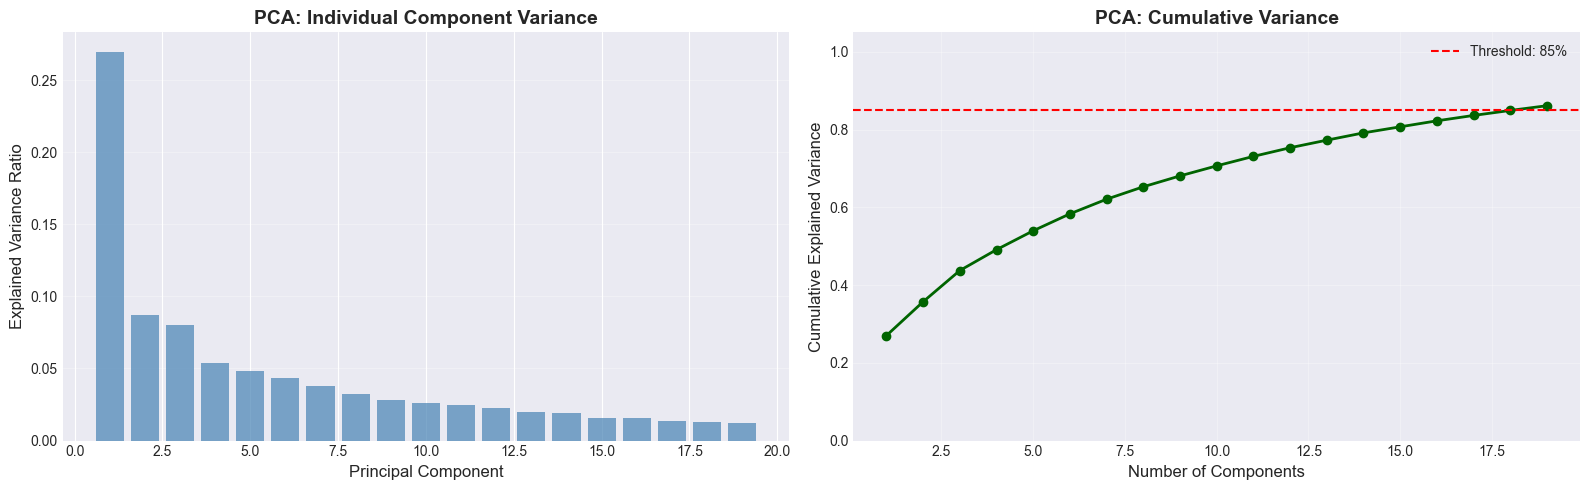


📊 Top 5 Feature Loadings per Component (first 3 PCs):

  PC1 (Variance: 27.0%):
    at                                          0.205
    lt                                          0.204
    revt                                        0.201
    sale                                        0.201
    ceq                                         0.199

  PC2 (Variance: 8.7%):
    cash_ratio_enhanced                         0.331
    cash_ratio                                  0.329
    quick_ratio                                 0.326
    current_ratio                               0.324
    fcf_trend                                   0.318

  PC3 (Variance: 8.0%):
    ebit_margin                                 0.312
    net_profit_margin                           0.302
    ebitda_margin                               0.276
    operating_margin                            0.276
    interest_coverage                           0.274
✓ Saved 'pca_model' to state (type: PCA)
✓ Saved 'pca_scale

In [15]:
# Apply PCA if enabled
if USE_PCA:
    print("\n🔄 Applying PCA...\n")
    
    # Use PCATransformer from src/
    from src._02_preprocessing.pca_transformer import PCATransformer
    
    pca_transformer = PCATransformer(
        n_components=PCA_VARIANCE_THRESHOLD,
        random_state=cfg['global']['random_state']
    )
    
    # Transform data (PCATransformer handles scaling internally)
    X_pca, pca_df = pca_transformer.fit_transform(df_cluster, feature_names)
    
    # Get metadata
    n_components = pca_transformer.pca.n_components_
    explained_variance = pca_transformer.pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    print(f"✅ PCA Applied:")
    print(f"  Original Features:     {df_cluster.shape[1]}")
    print(f"  Reduced Components:    {n_components}")
    print(f"  Variance Explained:    {cumulative_variance[-1]:.2%}")
    print(f"  Reduction:             {(1 - n_components/df_cluster.shape[1]):.1%}\n")
    
    # Create scree plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Individual variance
    ax1.bar(range(1, n_components+1), explained_variance, alpha=0.7, color='steelblue')
    ax1.set_xlabel('Principal Component', fontsize=12)
    ax1.set_ylabel('Explained Variance Ratio', fontsize=12)
    ax1.set_title('PCA: Individual Component Variance', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Cumulative variance
    ax2.plot(range(1, n_components+1), cumulative_variance, 'o-', linewidth=2, markersize=6, color='darkgreen')
    ax2.axhline(y=PCA_VARIANCE_THRESHOLD, color='red', linestyle='--', 
               label=f'Threshold: {PCA_VARIANCE_THRESHOLD:.0%}')
    ax2.set_xlabel('Number of Components', fontsize=12)
    ax2.set_ylabel('Cumulative Explained Variance', fontsize=12)
    ax2.set_title('PCA: Cumulative Variance Explained', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Use PCA-transformed data for clustering
    clustering_data = X_pca
    feature_names_for_clustering = pca_df.columns.tolist()
    
    # Save transformer for later use (inverse transform, etc.)
    pca_transformer_fitted = pca_transformer
    
else:
    print("\n⏭️  PCA Disabled - Using original features\n")
    clustering_data = df_cluster.values
    feature_names_for_clustering = feature_names
    pca_transformer_fitted = None

## 7️⃣ Data Scaling & Preparation

**Scale features for clustering algorithms.**

In [16]:
# ============================================================================
# 🎛️ SCALING CONFIGURATION
# ============================================================================

SCALER_TYPE = cfg['preprocessing']['scaling']['method']

print(f"\n🎛️ Scaling Configuration:")
print(f"  Scaler Type: {SCALER_TYPE.upper()}")


🎛️ Scaling Configuration:
  Scaler Type: STANDARD


In [17]:
# Apply scaling
if SCALER_TYPE == 'robust':
    scaler = RobustScaler()
elif SCALER_TYPE == 'minmax':
    scaler = MinMaxScaler()
else:  # 'standard' (default)
    scaler = StandardScaler()

X_scaled = scaler.fit_transform(clustering_data)

print(f"\n✅ Scaling applied using {SCALER_TYPE.upper()}Scaler")
print(f"  Scaled Data Shape:  {X_scaled.shape}")
print(f"  Mean:               {X_scaled.mean():.6f}")
print(f"  Std:                {X_scaled.std():.6f}")

# Save scaler
scaler_name = scaler


✅ Scaling applied using STANDARDScaler
  Scaled Data Shape:  (160, 19)
  Mean:               0.000000
  Std:                1.000000
✓ Saved 'scaler' to state (type: StandardScaler)
✓ Saved 'X_scaled' to state (type: ndarray)
✓ Saved 'clustering_features' to state (type: list)


## 8️⃣ K-Means Clustering

**Interactive K-Means with adjustable parameters.**

In [18]:
# Find optimal K using multiple methods
K_range = range(cfg['cluster_selection']['k_range'][0], 
                cfg['cluster_selection']['k_range'][1])

# Option 1: Use KSelector for automatic K determination (elbow, silhouette, gap)
# from src._03_clustering.k_selector import KSelector
# k_selector = KSelector(k_range=list(K_range), random_state=cfg['global']['random_state'])
# optimal_k, k_results = k_selector.find_optimal_k(X_scaled)

# Option 2: Manual K evaluation with all 4 metrics (for interactive exploration)
inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

print("\n🔄 Testing different K values...\n")

for k in K_range:
    kmeans = KMeans(
        n_clusters=k, 
        random_state=cfg['global']['random_state'],
        n_init=cfg['classification']['kmeans']['n_init']
    )
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    
    print(f"  K={k:2d}  |  Inertia: {kmeans.inertia_:8.2f}  |  Silhouette: {silhouette_scores[-1]:.3f}")

print("\n✅ Optimal K search completed")


🔄 Testing different K values...

  K= 2  |  Inertia:  2900.05  |  Silhouette:  0.591  |  Calinski-H:     7.62  |  Davies-Bouldin:  0.289
  K= 3  |  Inertia:  2769.42  |  Silhouette:  0.089  |  Calinski-H:     7.67  |  Davies-Bouldin:  2.647
  K= 4  |  Inertia:  2623.01  |  Silhouette:  0.203  |  Calinski-H:     8.27  |  Davies-Bouldin:  2.036
  K= 5  |  Inertia:  2482.74  |  Silhouette:  0.204  |  Calinski-H:     8.70  |  Davies-Bouldin:  1.900
  K= 6  |  Inertia:  2362.41  |  Silhouette:  0.037  |  Calinski-H:     8.83  |  Davies-Bouldin:  1.579
  K= 7  |  Inertia:  2259.64  |  Silhouette:  0.092  |  Calinski-H:     8.81  |  Davies-Bouldin:  1.526
  K= 8  |  Inertia:  2074.35  |  Silhouette:  0.362  |  Calinski-H:    10.11  |  Davies-Bouldin:  1.105
  K= 9  |  Inertia:  1983.76  |  Silhouette:  0.124  |  Calinski-H:    10.05  |  Davies-Bouldin:  1.366
  K=10  |  Inertia:  1837.92  |  Silhouette:  0.108  |  Calinski-H:    10.90  |  Davies-Bouldin:  1.188

✅ K-value testing complete


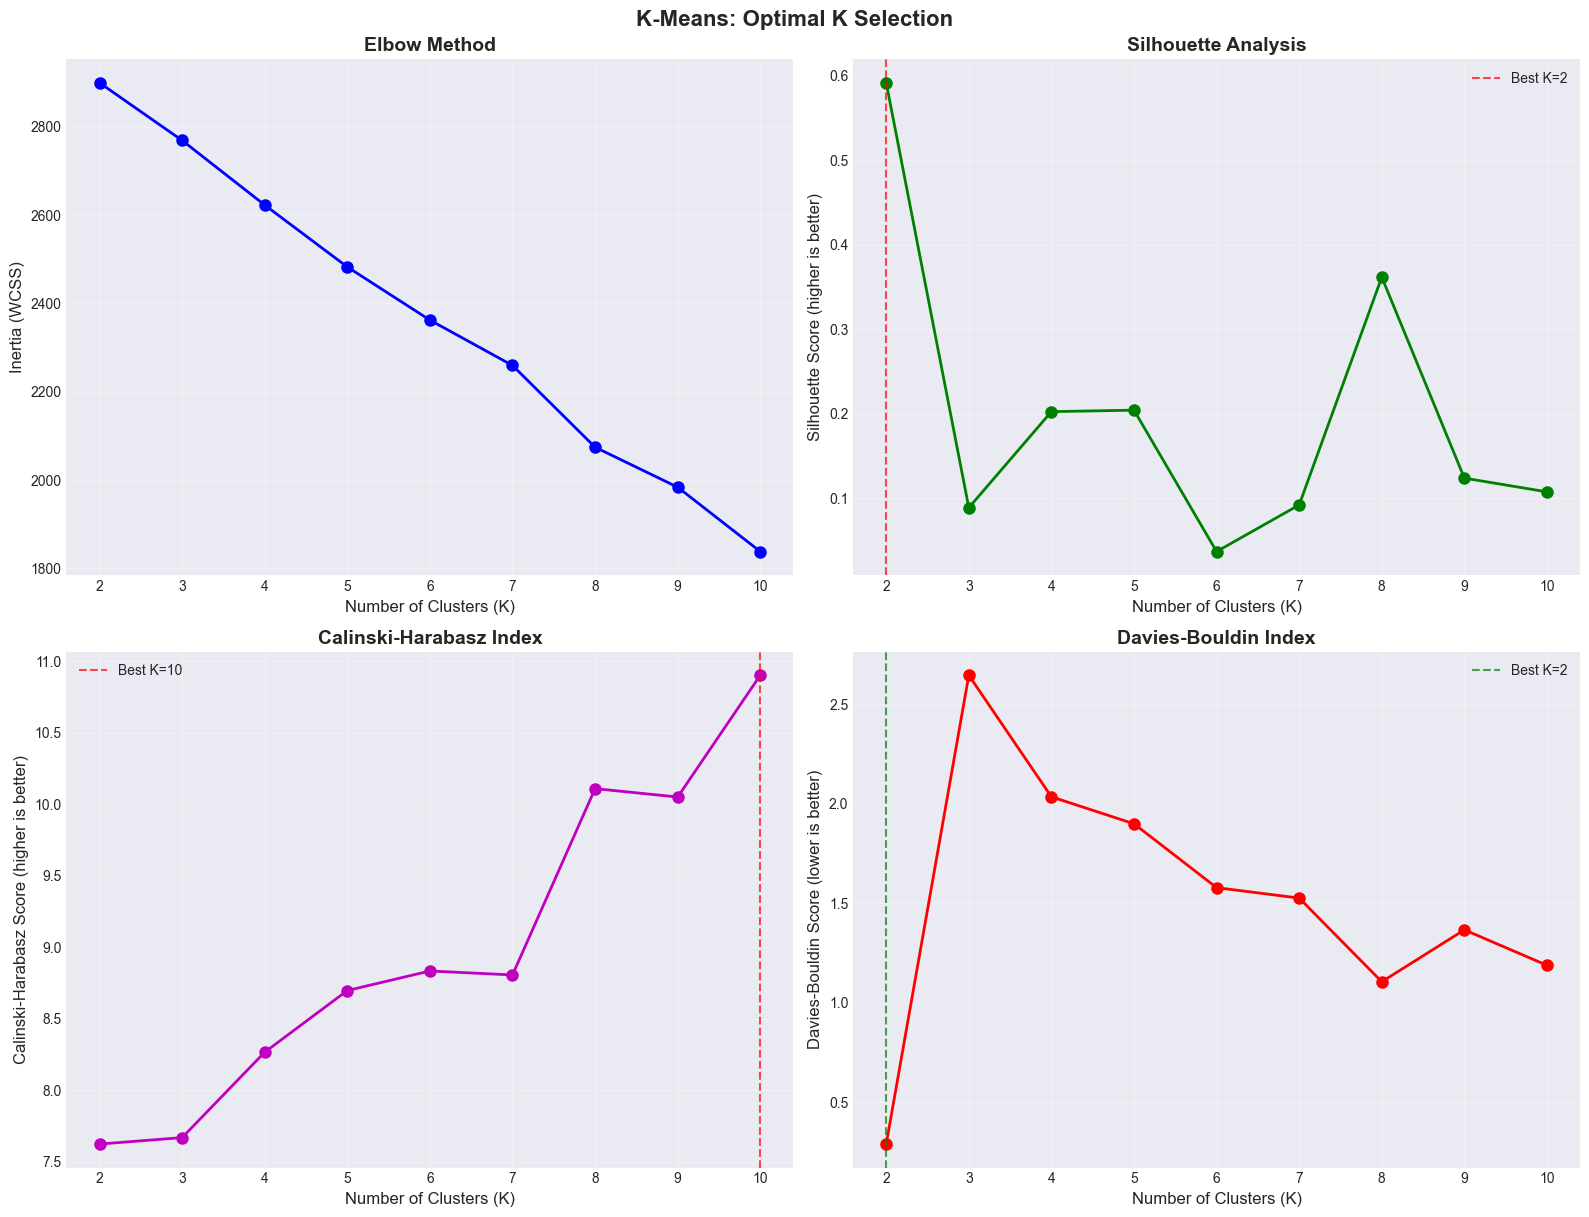


📊 Recommendations:
  Best Silhouette:       K = 2 (Score: 0.591)
  Best Calinski-Harabasz: K = 10 (Score: 10.90)
  Best Davies-Bouldin:    K = 2 (Score: 0.289)


In [19]:
# Visualize optimal K selection with interactive dashboard
fig = create_metrics_dashboard(
    k_range=K_range,
    inertias=inertias,
    silhouettes=silhouette_scores,
    calinskis=calinski_scores,
    davies_bouldins=davies_bouldin_scores,
    title='K-Means: Optimal K Selection',
    width=1400,
    height=800
)
fig.show()

# Print recommendations
best_sil_k = list(K_range)[np.argmax(silhouette_scores)]
best_cal_k = list(K_range)[np.argmax(calinski_scores)]
best_db_k = list(K_range)[np.argmin(davies_bouldin_scores)]

print(f"\n📊 Recommendations:")
print(f"  Best Silhouette:       K = {best_sil_k} (Score: {max(silhouette_scores):.3f})")
print(f"  Best Calinski-Harabasz: K = {best_cal_k} (Score: {max(calinski_scores):.2f})")
print(f"  Best Davies-Bouldin:    K = {best_db_k} (Score: {min(davies_bouldin_scores):.3f})")

In [20]:
# ============================================================================
# 🎛️ K-MEANS CONFIGURATION
# ============================================================================

# Option 1: Use auto-selected K from above analysis
# KMEANS_K = best_sil_k  # Or best_cal_k, or best_db_k

# Option 2: Use config default (can be changed in config.yaml)
KMEANS_K = cfg['static_analysis']['n_clusters']  # From config

# Option 3: Override manually
# KMEANS_K = 3  # Uncomment to manually set

# Other parameters from config
KMEANS_RANDOM_STATE = cfg['global']['random_state']
KMEANS_N_INIT = cfg['classification']['kmeans']['n_init']
KMEANS_MAX_ITER = cfg['classification']['kmeans']['max_iter']

print(f"\n🎛️ K-Means Configuration:")
print("=" * 80)
print(f"  K (clusters):      {KMEANS_K}")
print(f"  Random State:      {KMEANS_RANDOM_STATE}")
print(f"  N Init:            {KMEANS_N_INIT}")
print(f"  Max Iterations:    {KMEANS_MAX_ITER}")
print("=" * 80)


🎛️ K-Means Configuration:
  K (clusters):      3
  Random State:      42
  N Init:            10
  Max Iterations:    300


In [21]:
# Fit K-Means using KMeansClusterer from src/
from src._03_clustering.algorithms.kmeans import KMeansClusterer

print(f"\n🔄 Training K-Means with K={KMEANS_K}...\n")

# Create config for KMeansClusterer
kmeans_config = {
    'n_clusters': KMEANS_K,
    'n_init': KMEANS_N_INIT,
    'max_iter': KMEANS_MAX_ITER
}

# Initialize and fit clusterer
kmeans_clusterer = KMeansClusterer(
    config=kmeans_config,
    random_state=KMEANS_RANDOM_STATE
)

kmeans_labels = kmeans_clusterer.fit_predict(X_scaled)

# Get metrics using clusterer's method
metrics = kmeans_clusterer.get_metrics(X_scaled, kmeans_labels)

print("✅ K-Means clustering complete!\n")
print("📊 Quality Metrics:")
print("=" * 80)
print(f"  Inertia:              {metrics['inertia']:.2f}")
print(f"  Silhouette Score:     {metrics['silhouette']:.3f}  (range: -1 to 1, higher is better)")
print(f"  Calinski-Harabasz:    {metrics.get('calinski_harabasz', 'N/A')}")
print(f"  Davies-Bouldin:       {metrics['davies_bouldin']:.3f}  (lower is better)")
print(f"  Iterations:           {kmeans_clusterer.model.n_iter_}")
print("=" * 80)

# Add labels to dataframe
df_kmeans = df_latest.copy()
df_kmeans['cluster_kmeans'] = kmeans_labels

# Save results
state.save('kmeans_model', kmeans_clusterer.model)
state.save('kmeans_labels', kmeans_labels)
state.save('df_kmeans', df_kmeans)

# Save for comparison in Sektion 11
kmeans_inertia = metrics['inertia']
kmeans_silhouette = metrics['silhouette']
kmeans_calinski = metrics.get('calinski_harabasz', 0)
kmeans_davies_bouldin = metrics['davies_bouldin']


🔄 Training K-Means with K=3...

✅ K-Means clustering complete!

📊 Quality Metrics:
  Inertia:              2769.42
  Silhouette Score:     0.089  (range: -1 to 1, higher is better)
  Calinski-Harabasz:    7.67  (higher is better)
  Davies-Bouldin:       2.647  (lower is better)
  Iterations:           6
✓ Saved 'kmeans_model' to state (type: KMeans)
✓ Saved 'kmeans_labels' to state (type: ndarray)
✓ Saved 'df_kmeans' to state (type: DataFrame)


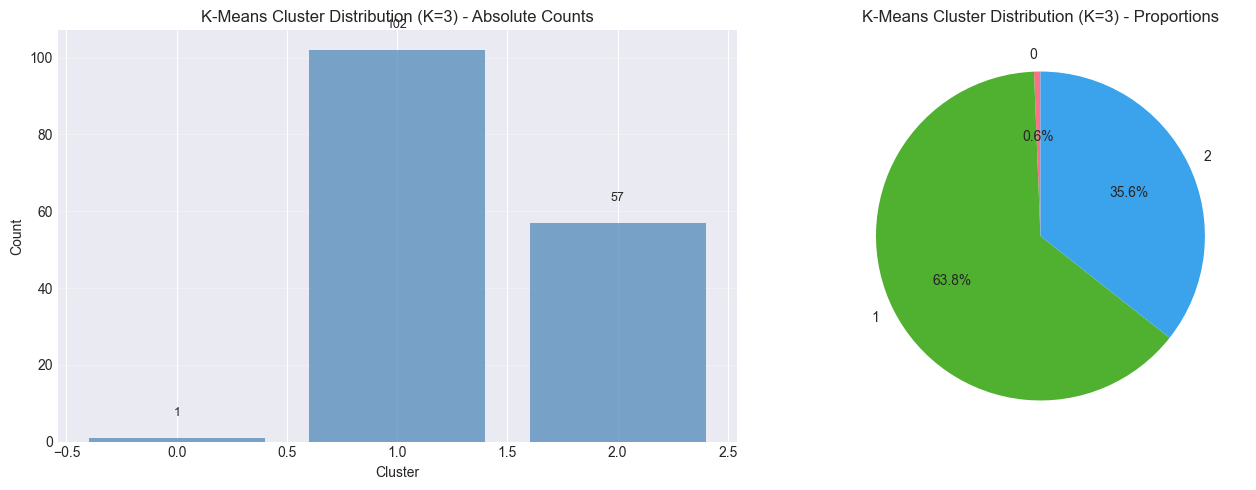


📊 Cluster Sizes:
  Cluster 0:     1 companies (  0.6%)
  Cluster 1:   102 companies ( 63.7%)
  Cluster 2:    57 companies ( 35.6%)


In [22]:
# Cluster distribution (interactive)
fig = create_interactive_cluster_distribution(
    df_kmeans,
    cluster_col='cluster_kmeans',
    title=f'K-Means Cluster Distribution (K={KMEANS_K})',
    show_pie=True,
    width=1200,
    height=500
)
fig.show()

# Print cluster sizes
cluster_counts = df_kmeans['cluster_kmeans'].value_counts().to_dict()
print(f"\n📊 Cluster Sizes:")
for cluster_id in sorted(cluster_counts.keys()):
    count = cluster_counts[cluster_id]
    pct = count / len(df_kmeans) * 100
    print(f"  Cluster {cluster_id}: {count:5d} companies ({pct:5.1f}%)")

In [23]:
# 1. Mini-Cluster und Haupt-Cluster identifizieren
cluster_counts = df_kmeans['cluster_kmeans'].value_counts()
mini_clusters = cluster_counts[cluster_counts <= 3].index.tolist()
main_clusters = sorted(cluster_counts[cluster_counts > 10].index.tolist())

print(f"Mini-Cluster (≤3 Unternehmen): {sorted(mini_clusters)}")
print(f"Haupt-Cluster (>10 Unternehmen): {main_clusters}")
print(f"\n{'='*100}\n")

# 2. Durchschnitte für jeden Haupt-Cluster berechnen
cluster_averages = {}
for cluster_id in main_clusters:
    cluster_averages[cluster_id] = df_kmeans[df_kmeans['cluster_kmeans'] == cluster_id][selected_features].mean()

# 3. Für jedes Outlier-Unternehmen
for mini_cluster_id in sorted(mini_clusters):
    cluster_companies = df_kmeans[df_kmeans['cluster_kmeans'] == mini_cluster_id]
    
    print(f"\n{'#'*100}")
    print(f"# CLUSTER {mini_cluster_id} ({len(cluster_companies)} Unternehmen)")
    print(f"{'#'*100}\n")
    
    for idx, row in cluster_companies.iterrows():
        print(f"🏢 {row['conm']}")
        print(f"{'='*100}\n")
        
        company_features = df_kmeans.loc[idx, selected_features]
        
        # Tabelle aufbauen
        comparison_data = []
        
        for feat in selected_features[:15]:  # Top 15 Features
            row_data = {'Feature': feat, 'Wert': f"{company_features[feat]:.2f}"}
            
            deviations = []
            
            # Für jeden Haupt-Cluster
            for cluster_id in main_clusters:
                cluster_avg = cluster_averages[cluster_id][feat]
                deviation = abs((company_features[feat] - cluster_avg) / cluster_avg * 100) if cluster_avg != 0 else 0
                
                row_data[f'C{cluster_id}_Avg'] = f"{cluster_avg:.2f}"
                row_data[f'C{cluster_id}_Dev'] = f"{deviation:.1f}%"
                deviations.append(deviation)
            
            # Markiere Maximum
            min_dev = min(deviations)
            for i, cluster_id in enumerate(main_clusters):
                if deviations[i] == min_dev:
                    row_data[f'C{cluster_id}_Dev'] = f"►► {deviations[i]:.1f}%"
            
            comparison_data.append(row_data)
        
        # DataFrame anzeigen
        df_comparison = pd.DataFrame(comparison_data)
        display(df_comparison)
        
        # Zusammenfassung
        print(f"\n📊 Durchschnittliche Abweichung pro Cluster:")
        for cluster_id in main_clusters:
            cluster_avg = cluster_averages[cluster_id]
            avg_dev = ((company_features - cluster_avg) / cluster_avg * 100).abs().mean()
            print(f"   Cluster {cluster_id}: {avg_dev:.1f}%")
        
        print(f"\n{'='*100}\n")

print("✅ Outlier-Analyse abgeschlossen")

Mini-Cluster (≤3 Unternehmen): [0]
Haupt-Cluster (>10 Unternehmen): [1, 2]



####################################################################################################
# CLUSTER 0 (1 Unternehmen)
####################################################################################################

🏢 ROCKET INTERNET SE



,Feature,Wert,C1_Avg,C1_Dev,C2_Avg,C2_Dev
0,rect,3330.78,4620.69,►► 27.9%,1773.72,87.8%
1,sale,14897.34,20727.59,►► 28.1%,7297.97,104.1%
2,dvt,49.71,464.70,89.3%,414.56,►► 88.0%
3,xrd,645.86,806.61,19.9%,593.42,►► 8.8%
4,cogs,10192.98,13953.89,►► 27.0%,4276.25,138.4%
5,seq,4898.40,9853.84,50.3%,5501.73,►► 11.0%
6,revt,1136.50,20727.59,94.5%,7049.76,►► 83.9%
7,naics,523999.00,234930.20,123.0%,389651.19,►► 34.5%
8,fincf,-243.70,-445.72,►► 45.3%,-523.71,53.5%
9,xint,3.00,414.43,99.3%,155.08,►► 98.1%



📊 Durchschnittliche Abweichung pro Cluster:
   Cluster 1: 1601.3%
   Cluster 2: 3029.5%


✅ Outlier-Analyse abgeschlossen


In [24]:
# Cluster profiling
if USE_PCA:
    # Profile using PCA components
    df_profile = df_kmeans.copy()
    for col in clustering_features:
        df_profile[col] = clustering_data[col]
    
    cluster_profiles = df_profile.groupby('cluster_kmeans')[clustering_features].mean()
    
    print("\n📊 Cluster Profiles (PCA Component Means):")
    display(cluster_profiles)
    
    # Also show original feature profiles
    original_profiles = df_kmeans.groupby('cluster_kmeans')[selected_features].mean()
    
    print("\n📊 Cluster Profiles (Original Feature Means - Top 20 features):")
    display(original_profiles[selected_features[:20]])
else:
    # Profile using original features
    cluster_profiles = df_kmeans.groupby('cluster_kmeans')[selected_features].mean()
    
    print("\n📊 Cluster Profiles (Feature Means):")
    display(cluster_profiles)

# Save profiles
state.save('kmeans_profiles', cluster_profiles)


📊 Cluster Profiles (PCA Component Means):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
cluster_kmeans,,,,,,,,,,,,,,,,,,,
0,-0.849038,-7.541802,21.837157,4.640604,1.335659,10.820818,-2.552132,-1.499594,2.471845,-1.198474,-5.869824,2.688421,-2.488365,3.655692,-1.309713,-0.777082,1.410943,-0.082910,-0.674085
1,0.524820,0.118621,-0.528651,0.291102,-0.366179,0.109889,-0.065696,-0.119065,-0.156535,0.198050,0.106745,0.090926,-0.172919,0.093411,-0.438806,0.154847,-0.176425,-0.046506,-0.236674
2,-0.924256,-0.079956,0.562898,-0.602334,0.631834,-0.386483,0.162336,0.239373,0.236749,-0.333380,-0.088038,-0.209876,0.353089,-0.231291,0.808209,-0.263461,0.290954,0.084675,0.435349



📊 Cluster Profiles (Original Feature Means - Top 20 features):


,rect,sale,dvt,xrd,cogs,seq,revt,naics,fincf,xint,capx,invt,ivst,dltt,at,gind,ppent,emp,ivch,che
cluster_kmeans,,,,,,,,,,,,,,,,,,,,
0,3330.779119,14897.341743,49.706000,645.861955,10192.977593,4898.400000,1136.500000,523999.000000,-243.695146,3.000000,833.539477,18.900000,33.200000,138.600000,5689.900000,255030.000000,42.600000,0.387000,NaN,1985.552514
1,4620.688324,20727.594784,464.703914,806.610973,13953.890216,9853.837431,20727.594784,234930.196078,-445.720972,414.431762,1365.099956,2896.487225,703.324196,7496.170529,31592.934363,267236.666667,8434.085059,47.749853,221.695375,2890.569441
2,1773.717353,7297.971995,414.562212,593.423179,4276.253309,5501.725667,7049.757193,389651.192982,-523.713336,155.077947,443.381551,669.789404,171.596393,3245.226456,13183.094246,369270.701754,2546.100088,26.753577,47.861412,1254.948693


✓ Saved 'kmeans_profiles' to state (type: DataFrame)


In [25]:
# PARAMETER: Wähle PCA-Komponenten (1-basiert!)
PC_X = 3  # Erste Komponente
PC_Y = 9  # Zweite Komponente

print("="*100)
print("🔍 SCHRITT 1: Analysiere beste PC-Kombinationen für Cluster-Trennung")
print("="*100 + "\n")

# Konvertiere zu Array falls DataFrame
X_array = X_scaled if isinstance(X_scaled, np.ndarray) else X_scaled.values

# Teste PC-Kombinationen
pc_scores = []
n_components_available = min(10, X_array.shape[1])

for i in range(n_components_available):
    for j in range(i+1, n_components_available):
        X_subset = X_array[:, [i, j]]
        sil_score = silhouette_score(X_subset, kmeans_labels)
        
        pc_scores.append({
            'PC1': i+1,
            'PC2': j+1,
            'Silhouette': sil_score
        })

df_pc_scores = pd.DataFrame(pc_scores).sort_values('Silhouette', ascending=False)

print("📊 Top 10 PC-Kombinationen:")
display(df_pc_scores.head(10))

print("\n" + "="*100)
print(f"📊 SCHRITT 2: Interaktive Visualisierung PC{PC_X} vs PC{PC_Y}")
print("="*100 + "\n")

# Hole die Komponenten
X_pc_x = X_array[:, PC_X-1]
X_pc_y = X_array[:, PC_Y-1]

# DataFrame für Plotly
df_plot = pd.DataFrame({
    f'PC{PC_X}': X_pc_x,
    f'PC{PC_Y}': X_pc_y,
    'Cluster': kmeans_labels,
    'Unternehmen': df_kmeans['conm'].values
})

# Varianz-Erklärung
if USE_PCA and 'pca' in dir():
    var_x = pca.explained_variance_ratio_[PC_X-1] * 100
    var_y = pca.explained_variance_ratio_[PC_Y-1] * 100
    xlabel = f'PC{PC_X} ({var_x:.1f}% Varianz)'
    ylabel = f'PC{PC_Y} ({var_y:.1f}% Varianz)'
else:
    xlabel = f'Komponente {PC_X}'
    ylabel = f'Komponente {PC_Y}'

# Interaktiver Plot
fig = px.scatter(
    df_plot,
    x=f'PC{PC_X}',
    y=f'PC{PC_Y}',
    color='Cluster',
    hover_name='Unternehmen',
    hover_data={f'PC{PC_X}': ':.2f', f'PC{PC_Y}': ':.2f', 'Cluster': True},
    title=f'K-Means Clustering: {xlabel} vs {ylabel}',
    color_discrete_sequence=px.colors.qualitative.Bold,
    width=1100,
    height=700
)

# Centroids
centroids_x = kmeans.cluster_centers_[:, PC_X-1]
centroids_y = kmeans.cluster_centers_[:, PC_Y-1]

fig.add_trace(go.Scatter(
    x=centroids_x,
    y=centroids_y,
    mode='markers',
    marker=dict(size=20, color='red', symbol='x', line=dict(width=3, color='black')),
    name='Centroids',
    hovertext=[f'Centroid Cluster {i}' for i in range(KMEANS_K)],
    hoverinfo='text'
))

fig.update_layout(
    xaxis_title=xlabel,
    yaxis_title=ylabel,
    font=dict(size=12),
    legend=dict(title='Cluster'),
    hovermode='closest'
)

from IPython.display import display
display(fig)

print("\n💡 TIPP: Ändere PC_X und PC_Y oben für andere Komponenten!")
print("         Nutze Top-Kombinationen aus der Tabelle für beste Trennung!")
print("="*100)

🔍 SCHRITT 1: Analysiere beste PC-Kombinationen für Cluster-Trennung

📊 Top 10 PC-Kombinationen:


,PC1,PC2,Silhouette
10,2,4,0.139043
14,2,8,0.130287
9,2,3,0.126210
12,2,6,0.119008
15,2,9,0.115187
11,2,5,0.112667
18,3,5,0.101418
17,3,4,0.099629
21,3,8,0.097930
22,3,9,0.091113



📊 SCHRITT 2: Interaktive Visualisierung PC3 vs PC9




💡 TIPP: Ändere PC_X und PC_Y oben für andere Komponenten!
         Nutze Top-Kombinationen aus der Tabelle für beste Trennung!


In [ ]:
# 3D Interactive Scatter Plot
print("="*100)
print("📊 SCHRITT 3: 3D Visualisierung mit PC1, PC2, PC3")
print("="*100 + "\n")

# Konvertiere zu Array falls DataFrame
X_array = X_scaled if isinstance(X_scaled, np.ndarray) else X_scaled.values

# Erstelle DataFrame mit ersten 3 Komponenten
df_3d_plot = pd.DataFrame({
    'PC1': X_array[:, 0],
    'PC2': X_array[:, 1],
    'PC3': X_array[:, 2],
    'cluster': kmeans_labels,
    'company_id': df_kmeans['conm'].values
})

# Varianz-Erklärung für Achsenbeschriftungen
if USE_PCA and 'pca' in dir():
    var_1 = pca.explained_variance_ratio_[0] * 100
    var_2 = pca.explained_variance_ratio_[1] * 100
    var_3 = pca.explained_variance_ratio_[2] * 100
    title_3d = f'K-Means Clusters in 3D PCA Space (PC1: {var_1:.1f}%, PC2: {var_2:.1f}%, PC3: {var_3:.1f}%)'
else:
    title_3d = 'K-Means Clusters in 3D Feature Space'

# Erstelle 3D Plot
fig_3d = create_interactive_scatter(
    df_3d_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster',
    title=title_3d,
    hover_data=['company_id'],
    width=1000,
    height=800
)

fig_3d.show()

print("\n💡 TIPP: Rotiere den 3D-Plot durch Klicken und Ziehen!")
print("         Zoom mit Mausrad, Doppelklick zum Zurücksetzen")
print("="*100)

In [ ]:
# ============================================================================
# 💾 SAVE K-MEANS RESULTS
# ============================================================================

print("\n💾 Saving K-Means results...\n")

# Ensure OutputHandler is set to kmeans mode
output_handler_kmeans = OutputHandler(
    market=MARKET,
    algorithm='kmeans',
    mode='comparative',
    base_dir='output'
)

# Save cluster data and profiles
output_handler_kmeans.save_cluster_data(
    df=df_kmeans,
    cluster_profiles=cluster_profiles,
    analysis_type='static',
    metrics={
        'inertia': kmeans_inertia,
        'silhouette': kmeans_silhouette,
        'calinski_harabasz': kmeans_calinski,
        'davies_bouldin': kmeans_davies_bouldin,
        'n_clusters': KMEANS_K
    }
)

# Save models
output_handler_kmeans.save_models(
    scaler=scaler_name,
    model=kmeans_clusterer.model,
    analysis_type='static',
    pca_model=pca_transformer_fitted.pca if USE_PCA and pca_transformer_fitted else None
)

print("✅ K-Means results saved to:")
print(f"  📁 {output_handler_kmeans.algorithm_dir}")
print(f"  📊 Cluster data: clustered_companies.csv")
print(f"  📈 Profiles: cluster_profiles.csv")
print(f"  🤖 Models: scaler.pkl, model.pkl")

## 9️⃣ Hierarchical Clustering

**Interactive hierarchical clustering with dendrograms.**

In [26]:
# ============================================================================
# 🎛️ HIERARCHICAL CLUSTERING CONFIGURATION
# ============================================================================

HIER_LINKAGE = cfg['classification']['hierarchical']['linkage']
HIER_N_CLUSTERS = KMEANS_K   # Use same K as K-Means for comparison
DENDROGRAM_SAMPLE = 500      # Number of samples for dendrogram (speeds up visualization)

print(f"\n🎛️ Hierarchical Clustering Configuration:")
print("=" * 80)
print(f"  Linkage Method:    {HIER_LINKAGE}")
print(f"  N Clusters:        {HIER_N_CLUSTERS}")
print(f"  Dendrogram Sample: {DENDROGRAM_SAMPLE}")
print("=" * 80)


🎛️ Hierarchical Clustering Configuration:
  Linkage Method:    ward
  N Clusters:        3
  Dendrogram Sample: 500



🔄 Generating dendrogram (using 160 samples)...



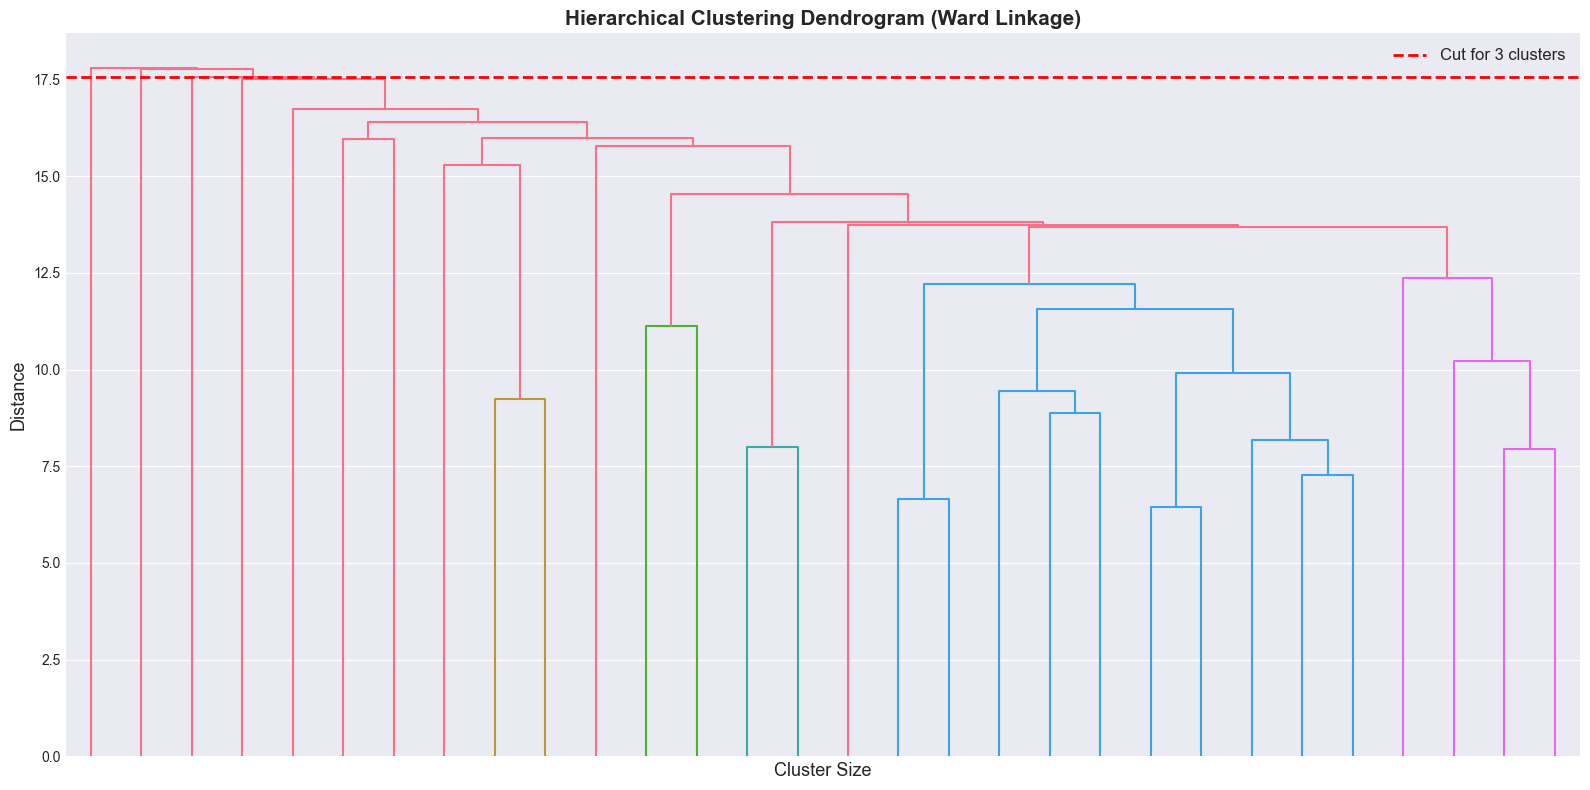

✅ Dendrogram generated


In [27]:
# Create dendrogram
print(f"\n🔄 Generating dendrogram (using {min(DENDROGRAM_SAMPLE, len(X_scaled))} samples)...\n")

# Sample data for dendrogram
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), min(DENDROGRAM_SAMPLE, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

# Calculate linkage
Z = linkage(X_sample, method=HIER_LINKAGE)

# Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_font_size=11,
          show_leaf_counts=True, no_labels=True)
plt.title(f'Hierarchical Clustering Dendrogram ({HIER_LINKAGE.capitalize()} Linkage)',
         fontsize=15, fontweight='bold')
plt.xlabel('Cluster Size', fontsize=13)
plt.ylabel('Distance', fontsize=13)

# Add cut line
if HIER_N_CLUSTERS <= len(Z):
    cut_height = Z[-HIER_N_CLUSTERS, 2]
    plt.axhline(y=cut_height, c='red', linestyle='--', linewidth=2,
               label=f'Cut for {HIER_N_CLUSTERS} clusters')
    plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

print("✅ Dendrogram generated")

In [28]:
# Fit hierarchical clustering using HierarchicalClusterer from src/
from src._03_clustering.algorithms.hierarchical import HierarchicalClusterer

print(f"\n🔄 Fitting hierarchical clustering on full dataset...\n")

# Create config for HierarchicalClusterer
hierarchical_config = {
    'n_clusters': HIER_N_CLUSTERS,
    'linkage': HIER_LINKAGE
}

# Initialize and fit clusterer
hierarchical_clusterer = HierarchicalClusterer(
    config=hierarchical_config,
    random_state=cfg['global']['random_state']
)

hier_labels = hierarchical_clusterer.fit_predict(X_scaled)

# Get metrics using clusterer's method
metrics = hierarchical_clusterer.get_metrics(X_scaled, hier_labels)

print("✅ Hierarchical clustering complete!\n")
print("📊 Quality Metrics:")
print("=" * 80)
print(f"  Silhouette Score:     {metrics['silhouette']:.3f}")
print(f"  Calinski-Harabasz:    {metrics.get('calinski_harabasz', 'N/A')}")
print(f"  Davies-Bouldin:       {metrics['davies_bouldin']:.3f}")
print("=" * 80)

# Add to dataframe
df_hier = df_latest.copy()
df_hier['cluster_hier'] = hier_labels

# Save results
state.save('hier_labels', hier_labels)
state.save('df_hier', df_hier)

# Save for comparison in Sektion 11
hier_silhouette = metrics['silhouette']
hier_calinski = metrics.get('calinski_harabasz', 0)
hier_davies_bouldin = metrics['davies_bouldin']


🔄 Fitting hierarchical clustering on full dataset...

✅ Hierarchical clustering complete!

📊 Quality Metrics:
  Silhouette Score:     0.614
  Calinski-Harabasz:    9.12
  Davies-Bouldin:       0.267
✓ Saved 'hier_labels' to state (type: ndarray)
✓ Saved 'df_hier' to state (type: DataFrame)


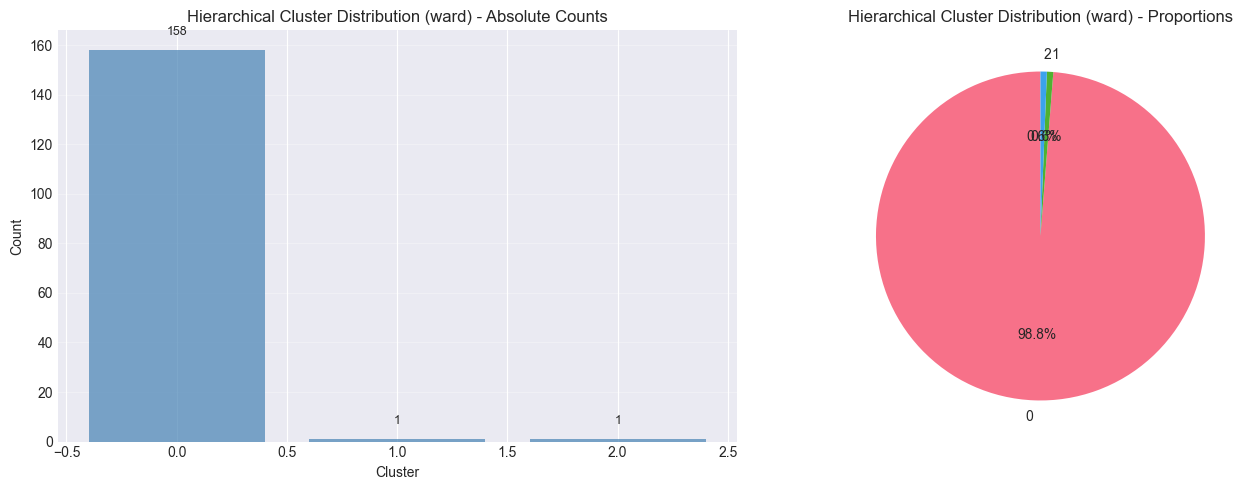


📊 Cluster Sizes:
  Cluster 0:   158 companies ( 98.8%)
  Cluster 1:     1 companies (  0.6%)
  Cluster 2:     1 companies (  0.6%)


In [29]:
# Cluster distribution
fig = create_interactive_cluster_distribution(
    df_hier,
    cluster_col='cluster_hier',
    title=f'Hierarchical Cluster Distribution (K={HIER_K})',
    show_pie=True,
    width=1200,
    height=500
)
fig.show()

# Get cluster counts for printing
hier_counts = df_hier['cluster_hier'].value_counts().to_dict()

print(f"\n📊 Cluster Sizes:")
for cluster_id in sorted(hier_counts.keys()):
    count = hier_counts[cluster_id]
    pct = count / len(df_hier) * 100
    print(f"  Cluster {cluster_id}: {count:5d} companies ({pct:5.1f}%)")

In [ ]:
# ============================================================================
# 💾 SAVE HIERARCHICAL RESULTS
# ============================================================================

print("\n💾 Saving Hierarchical results...\n")

# Calculate cluster profiles
if USE_PCA and pca_transformer_fitted:
    # Profile using PCA components
    df_profile_hier = df_hier.copy()
    for col in feature_names_for_clustering:
        if col in df_profile_hier.columns:
            continue
        # Get PCA component from clustering_data
        idx = feature_names_for_clustering.index(col)
        df_profile_hier[col] = clustering_data[:, idx]
    hier_cluster_profiles = df_profile_hier.groupby('cluster_hier')[feature_names_for_clustering].mean()
else:
    # Profile using original features
    hier_cluster_profiles = df_hier.groupby('cluster_hier')[selected_features].mean()

# Ensure OutputHandler is set to hierarchical mode
output_handler_hier = OutputHandler(
    market=MARKET,
    algorithm='hierarchical',
    mode='hierarchical',
    base_dir='output'
)

# Save cluster data and profiles
output_handler_hier.save_cluster_data(
    df=df_hier,
    cluster_profiles=hier_cluster_profiles,
    analysis_type='master_clustering',
    metrics={
        'silhouette': hier_silhouette,
        'calinski_harabasz': hier_calinski,
        'davies_bouldin': hier_davies_bouldin,
        'n_clusters': HIER_N_CLUSTERS,
        'linkage': HIER_LINKAGE
    }
)

# Save models
output_handler_hier.save_models(
    scaler=scaler_name,
    model=hierarchical_clusterer.model,
    analysis_type='master_clustering',
    pca_model=pca_transformer_fitted.pca if USE_PCA and pca_transformer_fitted else None
)

print("✅ Hierarchical results saved to:")
print(f"  📁 {output_handler_hier.algorithm_dir}")
print(f"  📊 Cluster data: clustered_companies.csv")
print(f"  📈 Profiles: cluster_profiles.csv")

## 🔟 DBSCAN Clustering

**Density-based clustering with automatic outlier detection.**

🔍 DBSCAN PARAMETER-BESTIMMUNG

🔄 Computing k-distance plot (k=5)...



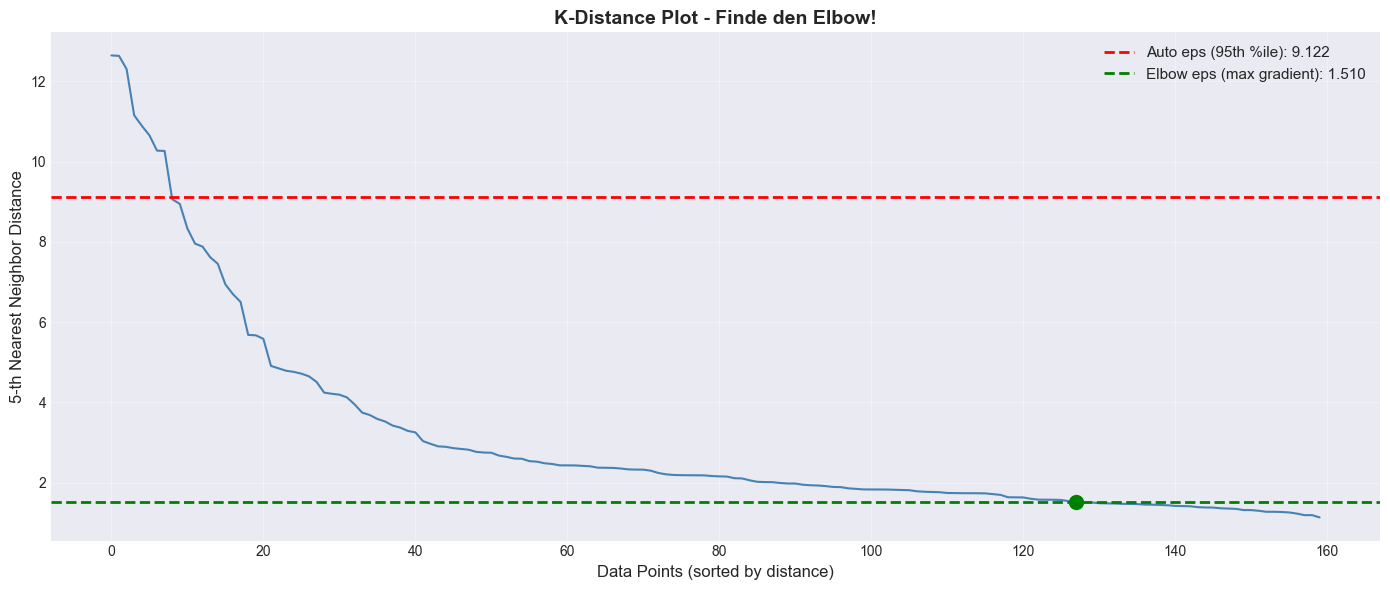


📊 EMPFOHLENE EPS-WERTE:
--------------------------------------------------------------------------------
  Percentile-Methode (95%): 9.122
  Elbow-Methode (größter Sprung): 1.510
  💡 Visueller Tipp: Schau wo der Knick im Plot ist!

🎛️ FINALE DBSCAN KONFIGURATION:
  Eps (ε):          4.000  (MANUELL)
  Min Samples:      5


In [30]:
# ============================================================================
# DBSCAN PARAMETER-BESTIMMUNG & KONFIGURATION
# ============================================================================

# 🎛️ PARAMETER: Config defaults (can override manually)
MIN_SAMPLES = cfg['classification']['dbscan']['min_samples']  # From config
EPS_PERCENTILE = 95           # Percentile für automatischen eps (niedriger = kleinerer eps)

# Option 1: Use config default eps
EPS_MANUAL = cfg['classification']['dbscan']['eps']

# Option 2: Calculate from K-Distance (uncomment to enable)
# EPS_MANUAL = None  # Will be calculated automatically

print("="*80)
print("🔍 DBSCAN PARAMETER-BESTIMMUNG")
print("="*80)
print(f"  Min Samples (from config): {MIN_SAMPLES}")
print(f"  Manual eps (from config):  {EPS_MANUAL}")

# K-distance plot
print(f"\n🔄 Computing k-distance plot (k={MIN_SAMPLES})...\n")

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances
k_distances = np.sort(distances[:, -1])[::-1]

# Berechne suggested eps
suggested_eps = np.percentile(k_distances, EPS_PERCENTILE)

# Finde "Elbow" visuell (größter Sprung)
# Gradient berechnen
gradients = np.diff(k_distances)
elbow_idx = np.argmax(gradients)
elbow_eps = k_distances[elbow_idx]

print(f"📊 Suggested eps values:")
print(f"  Percentile-based ({EPS_PERCENTILE}th):  {suggested_eps:.3f}")
print(f"  Elbow-based:                {elbow_eps:.3f}")

# Interactive K-Distance Plot
fig = create_k_distance_plot(
    distances=k_distances,
    optimal_eps=EPS_MANUAL if EPS_MANUAL is not None else suggested_eps,
    title='K-Distance Graph for DBSCAN eps Selection',
    width=1200,
    height=600
)
fig.show()

# Finale Parameter-Auswahl
if EPS_MANUAL is not None:
    final_eps = EPS_MANUAL
    print(f"\n✅ Using MANUAL eps: {final_eps:.3f}")
else:
    final_eps = suggested_eps
    print(f"\n✅ Using AUTOMATIC eps: {final_eps:.3f}")

print("="*80)

# Speichere für nächste Zelle
DBSCAN_EPS = final_eps
DBSCAN_MIN_SAMPLES = MIN_SAMPLES

In [31]:
# Fit DBSCAN using DBSCANClusterer from src/
from src._03_clustering.algorithms.dbscan import DBSCANClusterer

print(f"\n🔄 Running DBSCAN...\n")

# Create config for DBSCANClusterer
dbscan_config = {
    'eps': DBSCAN_EPS,
    'min_samples': DBSCAN_MIN_SAMPLES
}

# Initialize and fit clusterer
dbscan_clusterer = DBSCANClusterer(
    config=dbscan_config,
    random_state=cfg['global']['random_state']
)

dbscan_labels = dbscan_clusterer.fit_predict(X_scaled)

# Count clusters and outliers
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = list(dbscan_labels).count(-1)
n_outliers_pct = n_outliers / len(dbscan_labels) * 100

print("✅ DBSCAN complete!\n")
print("📊 Results:")
print("=" * 80)
print(f"  Clusters Found:       {n_clusters_dbscan}")
print(f"  Outliers:             {n_outliers} ({n_outliers_pct:.1f}%)")
print(f"  Clustered Points:     {len(dbscan_labels) - n_outliers} ({100-n_outliers_pct:.1f}%)")
print("=" * 80)

# Calculate metrics (excluding outliers)
if n_clusters_dbscan > 1 and n_outliers < len(dbscan_labels):
    mask_clustered = dbscan_labels != -1
    
    # Use DBSCANClusterer's get_metrics method
    metrics = dbscan_clusterer.get_metrics(X_scaled, dbscan_labels)
    
    print(f"\n📊 Quality Metrics (excluding outliers):")
    print("=" * 80)
    print(f"  Silhouette Score:     {metrics['silhouette']:.3f}")
    print(f"  Calinski-Harabasz:    {metrics.get('calinski_harabasz', 'N/A')}")
    print(f"  Davies-Bouldin:       {metrics['davies_bouldin']:.3f}")
    print("=" * 80)
    
    # Save metrics for comparison
    dbscan_silhouette = metrics['silhouette']
    dbscan_calinski = metrics.get('calinski_harabasz', 0)
    dbscan_davies_bouldin = metrics['davies_bouldin']
    
elif n_clusters_dbscan <= 1:
    print(f"\n⚠️  Only {n_clusters_dbscan} cluster(s) found. Try adjusting eps or min_samples.")
    dbscan_silhouette = 0
    dbscan_calinski = 0
    dbscan_davies_bouldin = 0
else:
    print(f"\n⚠️  All points are outliers. Try adjusting eps or min_samples.")
    dbscan_silhouette = 0
    dbscan_calinski = 0
    dbscan_davies_bouldin = 0

# Add to dataframe
df_dbscan = df_latest.copy()
df_dbscan['cluster_dbscan'] = dbscan_labels

# Save results
state.save('dbscan_labels', dbscan_labels)
state.save('df_dbscan', df_dbscan)


🔄 Running DBSCAN...

✅ DBSCAN complete!

📊 Results:
  Clusters Found:       1
  Outliers:             25 (15.6%)
  Clustered Points:     135 (84.4%)

⚠️  Only 1 cluster(s) found. Try adjusting eps or min_samples.
✓ Saved 'dbscan_labels' to state (type: ndarray)
✓ Saved 'df_dbscan' to state (type: DataFrame)


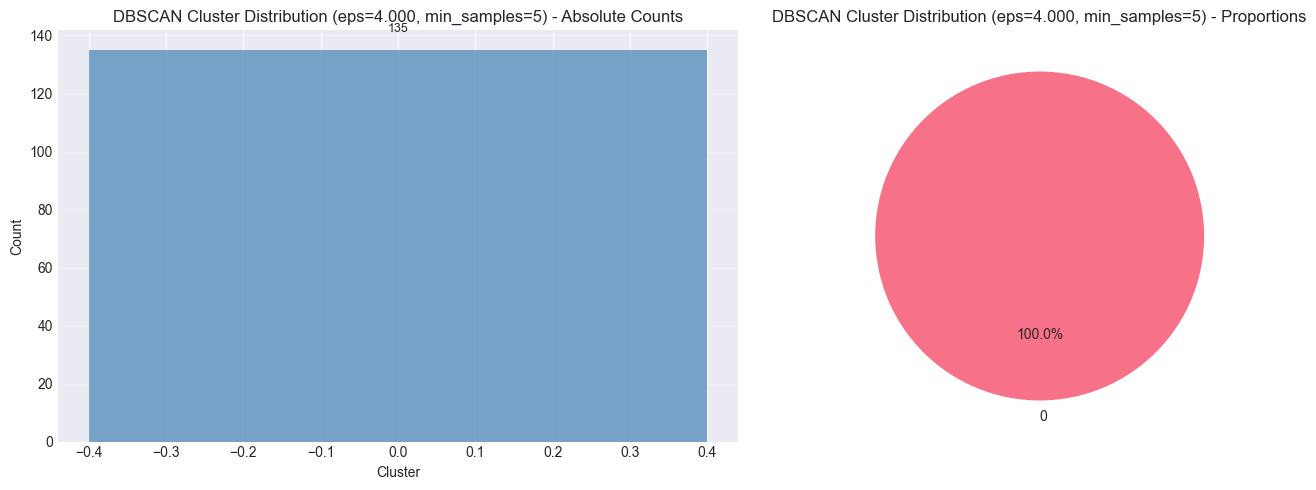


📊 Cluster Sizes (excluding 25 outliers):
  Cluster 0:   135 companies ( 84.4%)


In [32]:
# Cluster distribution (excluding outliers)
if n_clusters_dbscan > 0:
    df_dbscan_clustered = df_dbscan[df_dbscan['cluster_dbscan'] != -1]
    
    if len(df_dbscan_clustered) > 0:
        fig = create_interactive_cluster_distribution(
            df_dbscan_clustered,
            cluster_col='cluster_dbscan',
            title=f'DBSCAN Cluster Distribution (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})',
            show_pie=True,
            width=1200,
            height=500
        )
        fig.show()
        
        # Get cluster counts for printing
        dbscan_counts = df_dbscan_clustered['cluster_dbscan'].value_counts().to_dict()
        
        print(f"\n📊 Cluster Sizes (excluding {n_outliers} outliers):")
        for cluster_id in sorted(dbscan_counts.keys()):
            count = dbscan_counts[cluster_id]
            pct = count / len(df_dbscan) * 100
            print(f"  Cluster {cluster_id}: {count:5d} companies ({pct:5.1f}%)")
else:
    print("\n⚠️  No clusters to visualize")

In [ ]:
# ============================================================================
# 💾 SAVE DBSCAN RESULTS
# ============================================================================

print("\n💾 Saving DBSCAN results...\n")

# Calculate cluster profiles (excluding outliers)
if n_clusters_dbscan > 0 and n_outliers < len(dbscan_labels):
    # Filter out outliers (-1 labels)
    df_dbscan_clustered = df_dbscan[df_dbscan['cluster_dbscan'] != -1].copy()
    
    if USE_PCA and pca_transformer_fitted:
        # Profile using PCA components
        df_profile_dbscan = df_dbscan_clustered.copy()
        for col in feature_names_for_clustering:
            if col not in df_profile_dbscan.columns:
                # Get from clustering_data (non-outliers only)
                mask = dbscan_labels != -1
                idx = feature_names_for_clustering.index(col)
                df_profile_dbscan[col] = clustering_data[mask, idx]
        dbscan_cluster_profiles = df_profile_dbscan.groupby('cluster_dbscan')[feature_names_for_clustering].mean()
    else:
        # Profile using original features
        dbscan_cluster_profiles = df_dbscan_clustered.groupby('cluster_dbscan')[selected_features].mean()
else:
    # No valid clusters, create empty profiles
    dbscan_cluster_profiles = pd.DataFrame()

# Ensure OutputHandler is set to dbscan mode
output_handler_dbscan = OutputHandler(
    market=MARKET,
    algorithm='dbscan',
    mode='hierarchical',
    base_dir='output'
)

# Save cluster data and profiles
if len(dbscan_cluster_profiles) > 0:
    output_handler_dbscan.save_cluster_data(
        df=df_dbscan,
        cluster_profiles=dbscan_cluster_profiles,
        analysis_type='master_clustering',
        metrics={
            'silhouette': dbscan_silhouette if n_clusters_dbscan > 1 else 0,
            'calinski_harabasz': dbscan_calinski if n_clusters_dbscan > 1 else 0,
            'davies_bouldin': dbscan_davies_bouldin if n_clusters_dbscan > 1 else 0,
            'n_clusters': n_clusters_dbscan,
            'n_outliers': n_outliers,
            'outlier_pct': n_outliers_pct,
            'eps': DBSCAN_EPS,
            'min_samples': DBSCAN_MIN_SAMPLES
        }
    )
    
    # Save models
    output_handler_dbscan.save_models(
        scaler=scaler_name,
        model=dbscan_clusterer.model,
        analysis_type='master_clustering',
        pca_model=pca_transformer_fitted.pca if USE_PCA and pca_transformer_fitted else None
    )
    
    print("✅ DBSCAN results saved to:")
    print(f"  📁 {output_handler_dbscan.algorithm_dir}")
    print(f"  📊 Cluster data: clustered_companies.csv")
    print(f"  📈 Profiles: cluster_profiles.csv")
    print(f"  ⚠️  Note: {n_outliers} outliers marked with cluster -1")
else:
    print("⚠️  No valid clusters to save (all points are outliers or insufficient clusters)")

## 1️⃣1️⃣ Algorithm Comparison

**Compare all clustering algorithms side-by-side.**

In [33]:
# Compile metrics from all algorithms
comparison_data = []

# K-Means
comparison_data.append({
    'Algorithm': 'K-Means',
    'N_Clusters': KMEANS_K,
    'Silhouette': kmeans_silhouette,
    'Calinski-Harabasz': kmeans_calinski,
    'Davies-Bouldin': kmeans_davies_bouldin
})

# Hierarchical
comparison_data.append({
    'Algorithm': 'Hierarchical',
    'N_Clusters': HIER_N_CLUSTERS,
    'Silhouette': hier_silhouette,
    'Calinski-Harabasz': hier_calinski,
    'Davies-Bouldin': hier_davies_bouldin
})

# DBSCAN (if valid)
if n_clusters_dbscan > 1 and n_outliers < len(dbscan_labels):
    comparison_data.append({
        'Algorithm': 'DBSCAN',
        'N_Clusters': n_clusters_dbscan,
        'Silhouette': dbscan_silhouette,
        'Calinski-Harabasz': dbscan_calinski,
        'Davies-Bouldin': dbscan_davies_bouldin
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n📊 Algorithm Comparison:")
print("=" * 80)
display(df_comparison)
print("\nInterpretation:")
print("  • Silhouette:       Higher is better (range: -1 to 1)")
print("  • Calinski-Harabasz: Higher is better")
print("  • Davies-Bouldin:    Lower is better")
print("=" * 80)


📊 Algorithm Comparison:


,Algorithm,N_Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,3,0.089070,7.669647,2.646999
1,Hierarchical,3,0.614185,9.121254,0.266695



Interpretation:
  • Silhouette:       Higher is better (range: -1 to 1)
  • Calinski-Harabasz: Higher is better
  • Davies-Bouldin:    Lower is better


### 🎨 Parallel Coordinates: Multi-Dimensional Feature View

Parallel Coordinates zeigen alle Features gleichzeitig - Cluster sind farbcodiert.

In [ ]:
# ============================================================================
# PARALLEL COORDINATES PLOT - Multi-dimensional feature exploration
# ============================================================================

# Prepare data for parallel coordinates
# Use scaled features for better visualization
if USE_PCA:
    # If PCA is used, show original features (not PCA components)
    parallel_features = [col for col in selected_features if col in df_kmeans.columns][:8]  # Limit to 8 for readability
else:
    parallel_features = selected_features[:8]

# Create DataFrame with K-Means clusters for comparison
df_parallel = df_kmeans[parallel_features].copy()
df_parallel['cluster'] = df_kmeans['cluster_kmeans']

print(f"📊 Parallel Coordinates mit {len(parallel_features)} Features:\n{', '.join(parallel_features)}\n")

# Create interactive parallel coordinates plot
fig = create_parallel_coordinates(
    df_parallel,
    features=parallel_features,
    cluster_col='cluster',
    title='Parallel Coordinates: Feature Patterns by Cluster',
    width=1400,
    height=700
)
fig.show()

### 🔥 Cluster Profiles: Feature Heatmap

Durchschnittliche Feature-Werte pro Cluster (normalisiert für besseren Vergleich).

In [ ]:
# ============================================================================
# CLUSTER PROFILE HEATMAP - Average feature values per cluster
# ============================================================================

# Calculate cluster profiles (mean values per cluster)
cluster_profiles = df_parallel.groupby('cluster')[parallel_features].mean()

# Normalize for better visualization (z-score)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

print(f"📊 Cluster Profile Matrix: {cluster_profiles.shape[0]} Cluster × {cluster_profiles.shape[1]} Features\n")
print(cluster_profiles.round(3))
print("\n")

# Create interactive heatmap
fig = create_interactive_heatmap(
    cluster_profiles_norm,
    title='Cluster Profiles: Normalized Feature Averages',
    x_label='Features',
    y_label='Cluster',
    colorscale='RdBu_r',
    show_values=True,
    width=1400,
    height=max(400, 100 * len(cluster_profiles))
)
fig.show()

In [ ]:
# ============================================================================
# ALGORITHM COMPARISON: Interactive Metrics Dashboard
# ============================================================================

# Create comparison DataFrame for interactive plots
comparison_results = {}
for _, row in df_comparison.iterrows():
    comparison_results[row['Algorithm']] = {
        'silhouette': row['Silhouette'],
        'calinski_harabasz': row['Calinski-Harabasz'],
        'davies_bouldin': row['Davies-Bouldin']
    }

# Create comparison DataFrame
metrics_data = {
    'Algorithm': list(comparison_results.keys()),
    'Silhouette': [comparison_results[alg]['silhouette'] for alg in comparison_results.keys()],
    'Calinski-Harabasz': [comparison_results[alg]['calinski_harabasz'] for alg in comparison_results.keys()],
    'Davies-Bouldin': [comparison_results[alg]['davies_bouldin'] for alg in comparison_results.keys()]
}
df_metrics = pd.DataFrame(metrics_data)

# Create interactive bar chart comparison
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Silhouette Score', 'Calinski-Harabasz Score', 'Davies-Bouldin Score')
)

# Silhouette
fig.add_trace(
    go.Bar(x=df_metrics['Algorithm'], y=df_metrics['Silhouette'],
           marker_color='green', name='Silhouette',
           hovertemplate='<b>%{x}</b><br>Score: %{y:.3f}<extra></extra>'),
    row=1, col=1
)

# Calinski-Harabasz
fig.add_trace(
    go.Bar(x=df_metrics['Algorithm'], y=df_metrics['Calinski-Harabasz'],
           marker_color='orange', name='Calinski-Harabasz',
           hovertemplate='<b>%{x}</b><br>Score: %{y:.2f}<extra></extra>'),
    row=1, col=2
)

# Davies-Bouldin
fig.add_trace(
    go.Bar(x=df_metrics['Algorithm'], y=df_metrics['Davies-Bouldin'],
           marker_color='red', name='Davies-Bouldin',
           hovertemplate='<b>%{x}</b><br>Score: %{y:.3f}<extra></extra>'),
    row=1, col=3
)

fig.update_yaxes(title_text="Score", row=1, col=1)
fig.update_yaxes(title_text="Score", row=1, col=2)
fig.update_yaxes(title_text="Score (lower is better)", row=1, col=3)

fig.update_layout(
    title_text='Algorithm Comparison: Quality Metrics',
    showlegend=False,
    width=1600,
    height=500
)
fig.show()

In [ ]:
# Calculate Adjusted Rand Index (agreement between algorithms)
algorithms = ['K-Means', 'Hierarchical']
labels_list = [kmeans_labels, hier_labels]

if n_clusters_dbscan > 1:
    algorithms.append('DBSCAN')
    labels_list.append(dbscan_labels)

n_algs = len(algorithms)
ari_matrix = np.ones((n_algs, n_algs))

for i in range(n_algs):
    for j in range(i+1, n_algs):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        ari_matrix[i, j] = ari
        ari_matrix[j, i] = ari

df_ari = pd.DataFrame(ari_matrix, index=algorithms, columns=algorithms)

print("\n📊 Adjusted Rand Index (Algorithm Agreement):")
print("=" * 80)
display(df_ari)
print("\nInterpretation:")
print("  • 1.0 = Perfect agreement")
print("  • 0.0 = Random agreement")
print("  • Negative = Less agreement than random")
print("=" * 80)


# Visualize ARI with interactive heatmap
fig = create_interactive_heatmap(
    df_ari,
    title='Algorithm Agreement: Adjusted Rand Index (ARI)',
    x_label='Algorithm',
    y_label='Algorithm',
    colorscale='RdYlGn',
    show_values=True,
    width=800,
    height=700
)
fig.show()

In [ ]:
# ============================================================================
# VISUAL COMPARISON: Interactive Multi-Algorithm Scatter
# ============================================================================

# Create 2D PCA projection for visualization
pca_viz = PCA(n_components=2, random_state=42)
X_pca_2d = pca_viz.fit_transform(X_scaled)
explained_var_viz = pca_viz.explained_variance_ratio_

print(f"📊 2D PCA für Visualisierung: {explained_var_viz.sum()*100:.1f}% Varianz erklärt\n")

# Create DataFrame with PCA components and cluster assignments
df_pca_all = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1]
})

# Add cluster assignments from each algorithm
df_pca_all['K-Means'] = kmeans_labels
df_pca_all['Hierarchical'] = hier_labels

if n_clusters_dbscan > 1:
    df_pca_all['DBSCAN'] = dbscan_labels
    algorithms_to_compare = ['K-Means', 'Hierarchical', 'DBSCAN']
else:
    algorithms_to_compare = ['K-Means', 'Hierarchical']

# Create interactive multi-algorithm comparison
fig = compare_clusters_interactive(
    df_pca_all,
    algorithms=algorithms_to_compare,
    x='PC1',
    y='PC2',
    title='Cluster Comparison Across Algorithms (PCA Space)',
    width=1600,
    height=600
)
fig.show()

## 1️⃣2️⃣ Advanced Interactive Visualizations

**8 advanced interactive charts for deep cluster analysis:**
- Sankey Diagram (Cluster Flow)
- PCA Biplot (Feature Arrows)
- Company Radar Chart
- Feature Importance Bubble
- Similarity Network
- Cluster Comparison Bars
- GICS Sunburst
- Outlier Analysis

In [ ]:
# ============================================================================
# 1. SANKEY DIAGRAM - Cluster Flow Between Algorithms
# ============================================================================

print("🔀 Creating Sankey Diagram (Cluster Flow)...\n")

# Prepare data with all cluster assignments
df_flow = df_latest.copy()
df_flow['cluster_kmeans'] = kmeans_labels
df_flow['cluster_hierarchical'] = hier_labels
df_flow['cluster_dbscan'] = dbscan_labels

fig_sankey = create_sankey_cluster_flow(
    df_flow,
    cluster_cols=['cluster_kmeans', 'cluster_hierarchical', 'cluster_dbscan'],
    algorithm_names=['K-Means', 'Hierarchical', 'DBSCAN'],
    title='Company Flow Between Clustering Algorithms',
    width=1400,
    height=900
)
fig_sankey.show()

print("\n💡 TIPP: Hover über Flüsse um zu sehen, welche Unternehmen wechseln!")
print("         Dicke Flüsse = viele Unternehmen bleiben zusammen")

In [ ]:
# ============================================================================
# 2. PCA BIPLOT - Features as Arrows
# ============================================================================

if USE_PCA and pca_transformer_fitted:
    print("📈 Creating PCA Biplot with Feature Arrows...\n")
    
    fig_biplot = create_pca_biplot(
        X_pca=clustering_data,
        pca_model=pca_transformer_fitted.pca,
        feature_names=selected_features[:8],  # Limit for readability
        cluster_labels=kmeans_labels,
        company_names=df_latest['conm'].tolist(),
        title='PCA Biplot: Companies + Feature Loadings',
        arrow_scale=3.0,
        width=1400,
        height=1000
    )
    fig_biplot.show()
    
    print("\n💡 TIPP: Rote Pfeile zeigen Feature-Richtungen!")
    print("         Unternehmen in Pfeil-Richtung haben hohe Werte für dieses Feature")
else:
    print("⚠️  PCA nicht aktiviert - Biplot benötigt PCA-Transformation")

In [ ]:
# ============================================================================
# 3. COMPANY RADAR CHART - Individual Company Analysis
# ============================================================================

print("🎯 Creating Company Radar Chart...\n")

# Select a company to highlight (you can change this!)
SELECTED_COMPANY = df_kmeans['conm'].iloc[0]  # First company, change as needed
# Example: SELECTED_COMPANY = 'Siemens AG'

# Prepare data with cluster and features
df_radar = df_kmeans[['conm'] + selected_features[:8]].copy()
df_radar['cluster'] = kmeans_labels

fig_radar = create_company_radar_chart(
    df_radar,
    features=selected_features[:8],
    company_col='conm',
    cluster_col='cluster',
    selected_company=SELECTED_COMPANY,
    title=f'{SELECTED_COMPANY} vs Cluster Averages',
    width=900,
    height=800
)
fig_radar.show()

print(f"\n📊 Zeigt {SELECTED_COMPANY} (schwarze Linie) vs Cluster-Durchschnitte")
print("💡 TIPP: Ändere SELECTED_COMPANY um andere Unternehmen zu analysieren!")

In [ ]:
# ============================================================================
# 4. FEATURE IMPORTANCE BUBBLE CHART
# ============================================================================

print("🫧 Creating Feature Importance Bubble Chart...\n")

df_bubble = df_kmeans[selected_features[:10]].copy()
df_bubble['cluster'] = kmeans_labels

fig_bubble = create_feature_importance_bubble(
    df_bubble,
    features=selected_features[:10],
    cluster_col='cluster',
    title='Feature Deviations by Cluster (Z-Scores)',
    width=1600,
    height=600
)
fig_bubble.show()

print("\n💡 LEGENDE:")
print("   - Bubble-Größe = Stärke der Abweichung vom Durchschnitt")
print("   - Rot = Cluster hat NIEDRIGERE Werte als Durchschnitt")
print("   - Blau = Cluster hat HÖHERE Werte als Durchschnitt")

In [ ]:
# ============================================================================
# 5. COMPANY SIMILARITY NETWORK
# ============================================================================

print("🕸️  Creating Company Similarity Network...\n")
print("⏳ Berechne MDS Layout (kann 10-30 Sekunden dauern)...\n")

df_network = df_kmeans[['conm'] + selected_features].copy()
df_network['cluster'] = kmeans_labels

fig_network = create_company_similarity_network(
    df_network,
    features=selected_features,
    cluster_col='cluster',
    company_col='conm',
    n_neighbors=3,  # Each company connected to 3 most similar
    title='Company Similarity Network (3 Nearest Neighbors)',
    width=1400,
    height=1000
)
fig_network.show()

print("\n💡 INTERPRETATION:")
print("   - Nahe Punkte = ähnliche Unternehmen")
print("   - Linien = direkte Ähnlichkeitsverbindungen")
print("   - Farben = Cluster-Zugehörigkeit")

In [ ]:
# ============================================================================
# 6. DYNAMIC CLUSTER COMPARISON
# ============================================================================

print("📊 Creating Cluster Comparison Chart...\n")

# Compare two clusters (adjust as needed)
CLUSTER_A = 0  # First cluster
CLUSTER_B = 1  # Second cluster

df_compare = df_kmeans[selected_features[:10]].copy()
df_compare['cluster'] = kmeans_labels

fig_compare = create_cluster_comparison_bars(
    df_compare,
    features=selected_features[:10],
    cluster_col='cluster',
    cluster_a=CLUSTER_A,
    cluster_b=CLUSTER_B,
    title=f'Feature Comparison: Cluster {CLUSTER_A} vs Cluster {CLUSTER_B}',
    width=1400,
    height=700
)
fig_compare.show()

print(f"\n📈 Vergleich von Cluster {CLUSTER_A} (blau) mit Cluster {CLUSTER_B} (rot)")
print("💡 TIPP: Ändere CLUSTER_A und CLUSTER_B für andere Vergleiche!")

In [ ]:
# ============================================================================
# 7. GICS SUNBURST CHART - Industry Hierarchy
# ============================================================================

print("☀️  Creating GICS Sunburst Chart...\n")

# Check for GICS column
gics_col = None
for col in ['gics_industry', 'gics', 'industry', 'sector']:
    if col in df_kmeans.columns:
        gics_col = col
        break

if gics_col:
    df_sunburst = df_kmeans[['conm', gics_col]].copy()
    df_sunburst['cluster'] = kmeans_labels
    
    fig_sunburst = create_sunburst_gics_clusters(
        df_sunburst,
        gics_col=gics_col,
        cluster_col='cluster',
        company_col='conm',
        title=f'Hierarchy: {gics_col.upper()} → Cluster → Companies',
        width=1100,
        height=1100
    )
    fig_sunburst.show()
    
    print("\n💡 INTERAKTION:")
    print("   - Klicke auf einen Ring um reinzuzoomen")
    print("   - Klicke auf Mitte um rauszuzoomen")
    print("   - Hover für Details")
else:
    print("⚠️  Keine GICS/Industry Spalte gefunden")
    print(f"   Verfügbare Spalten: {df_kmeans.columns.tolist()[:10]}")

In [ ]:
# ============================================================================
# 8. OUTLIER ANALYSIS - Distance to Cluster Center
# ============================================================================

print("⚠️  Creating Outlier Analysis Chart...\n")

# Threshold: Top 10% most distant companies are outliers
OUTLIER_PERCENTILE = 90  # Adjust as needed

fig_outlier = create_outlier_analysis_scatter(
    df_kmeans,
    X_scaled=X_scaled,
    cluster_labels=kmeans_labels,
    company_col='conm',
    threshold_percentile=OUTLIER_PERCENTILE,
    title='Outlier Analysis: Companies Far from Cluster Centers',
    width=1400,
    height=800
)
fig_outlier.show()

print(f"\n🔍 Unternehmen im Top {100-OUTLIER_PERCENTILE}% der Distanzen sind als Outlier markiert")
print("💡 INTERPRETATION:")
print("   - ⭐ Sterne = potenzielle Outlier/Grenzfälle")
print("   - Farbe = Distanz zum Cluster-Zentrum")
print("   - Diese Unternehmen passen evtl. nicht gut ins Cluster")

## 1️⃣3️⃣ Results Export

**Save cluster assignments and visualizations.**

In [39]:
# ============================================================================
# 💾 FINAL EXPORT: Cross-Algorithm Comparison Report
# ============================================================================

print("\n💾 Creating final cross-algorithm comparison report...\n")

# Create unified dataframe with all cluster assignments
df_final = df_latest.copy()
df_final['cluster_kmeans'] = kmeans_labels
df_final['cluster_hierarchical'] = hier_labels
df_final['cluster_dbscan'] = dbscan_labels

# Save to comparisons directory
output_handler_comparison = OutputHandler(
    market=MARKET,
    algorithm='kmeans',  # Doesn't matter for comparisons
    mode='auto',
    base_dir='output'
)

# Save comparison data
output_handler_comparison.save_comparison_data(
    comp_type='algorithms',
    data=df_final,
    filename='all_cluster_assignments.csv'
)

# Create algorithm comparison metrics table
comparison_metrics = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'N_Clusters': [KMEANS_K, HIER_N_CLUSTERS, n_clusters_dbscan],
    'Silhouette': [kmeans_silhouette, hier_silhouette, dbscan_silhouette if n_clusters_dbscan > 1 else 0],
    'Calinski-Harabasz': [kmeans_calinski, hier_calinski, dbscan_calinski if n_clusters_dbscan > 1 else 0],
    'Davies-Bouldin': [kmeans_davies_bouldin, hier_davies_bouldin, dbscan_davies_bouldin if n_clusters_dbscan > 1 else 0],
    'Parameters': [
        f'K={KMEANS_K}, n_init={KMEANS_N_INIT}',
        f'linkage={HIER_LINKAGE}',
        f'eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}'
    ]
})

output_handler_comparison.save_comparison_data(
    comp_type='algorithms',
    data=comparison_metrics,
    filename='algorithm_metrics_comparison.csv'
)

print("✅ Final exports created:")
print(f"  📁 Output directory: {output_handler_comparison.comparisons_dir / 'algorithms'}")
print(f"  📊 All cluster assignments: all_cluster_assignments.csv")
print(f"  📈 Algorithm metrics: algorithm_metrics_comparison.csv")
print(f"\n{'='*80}")
print(f"\n🎉 All results saved to: output/{MARKET}/")
print(f"\n   Struktur:")
print(f"   ├── 01_data/                   # Processed features")
print(f"   ├── 02_algorithms/")
print(f"   │   ├── kmeans_comparative/    # K-Means results")
print(f"   │   ├── hierarchical/          # Hierarchical results")
print(f"   │   └── dbscan/                # DBSCAN results")
print(f"   ├── 03_comparisons/")
print(f"   │   └── algorithms/            # Cross-algorithm comparison")
print(f"   └── 99_summary/                # Summary reports")
print(f"\n{'='*80}")


📁 Output Directory: /Users/tobi/Documents/GitHub/Masterarbeit-Kennzahlenanalyse/output/germany/notebooks/master_workflow

✅ Exported cluster assignments: cluster_assignments.csv
✅ Exported comparison metrics: algorithm_comparison.csv
✅ Exported ARI matrix: algorithm_agreement_ari.csv
✅ Exported configuration: configuration_summary.txt

  ✅ ALL RESULTS EXPORTED TO: /Users/tobi/Documents/GitHub/Masterarbeit-Kennzahlenanalyse/output/germany/notebooks/master_workflow


## 🎉 Workflow Complete!

### What you accomplished:

1. ✅ Loaded and preprocessed data
2. ✅ Analyzed and handled outliers
3. ✅ Selected features (static/dynamic/combined)
4. ✅ Applied PCA for dimensionality reduction (if enabled)
5. ✅ Ran K-Means clustering with optimal k-selection
6. ✅ Ran Hierarchical clustering with dendrograms
7. ✅ Ran DBSCAN with automatic outlier detection
8. ✅ Compared all algorithms side-by-side
9. ✅ Exported results and visualizations

### 🔄 Want to try something different?

**Jump back to any section and adjust parameters:**
- Change feature set (Section 5)
- Toggle PCA on/off (Section 6)
- Try different k values (Section 8)
- Adjust DBSCAN parameters (Section 10)
- Compare different configurations

### 📊 Next steps:

- Analyze cluster profiles in detail
- Investigate outliers from DBSCAN
- Run the main.py pipeline for production results
- Export findings for your Masterarbeit

---

**Happy clustering! 🎯**